# Tugas 2 - Klasifikasi Diabetes dengan Naive Bayes dan Logistic Regression

| Nama | NRP |
|------|-----|
| Aziz Rahmad Arifin| 5054251002|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Pima Indians Diabetes Dataset. Dataset bisa diakses melalui link berikut:\
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

Tujuan utama dari tugas ini adalah membangun model Naive Bayes dan Logistic Regression untuk mengklasifikasikan apakah seorang pasien menderita diabetes atau tidak.

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Gaussian Naive Bayes dan Logistic Regression.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil kedua model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [67]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

# PERBAIKAN: dibungkus try/except agar notebook tetap dapat dijalankan
# di luar lingkungan Kaggle (kagglehub hanya tersedia di Kaggle).
try:
    import kagglehub
    # kagglehub.dataset_download('<owner>/<dataset-slug>')
except ModuleNotFoundError:
    print('kagglehub tidak tersedia (bukan lingkungan Kaggle) - dilewati.')

/kaggle/input/datasets/jamaltariqcheema/pima-indians-diabetes-dataset/diabetes.csv


In [68]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
classification_report, confusion_matrix, ConfusionMatrixDisplay,
accuracy_score, precision_score, recall_score, f1_score,
roc_curve, roc_auc_score
)


RANDOM_STATE= 42
sns.set_style('whitegrid')

### Baca Data Frame dan Melihat 5 baris pertama

In [69]:
# PERBAIKAN:
# Path Kaggle dipertahankan, tetapi diberi fallback ke file lokal agar notebook
# tetap dapat dijalankan ulang (reproducible) di luar lingkungan Kaggle.
import os

kaggle_path = '/kaggle/input/datasets/jamaltariqcheema/pima-indians-diabetes-dataset/diabetes.csv'
csv_path = kaggle_path if os.path.exists(kaggle_path) else 'diabetes.csv'

data = pd.read_csv(csv_path)
df = data.copy(deep=True)
data.head(5)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


### Cek informasi dasar dataset

In [70]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


### Mengecek bentuk dimensi dari data

In [71]:
data.shape

(768, 9)

### Mengecek nilai null

In [72]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

**Note:** `isnull().sum()` hanya mendeteksi nilai `NaN` Bukan nilai yang tidak valid secara medis seperti `Glukosa=0, dsb.`

### Statistika Deskriptif

In [73]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Analisis Statistika Deskriptif

Dari `data.describe()`, seluruh variabel memiliki **count = 768** (tidak ada `NaN`).

- **`Outcome`**: mean 0,349 → sekitar **34,9% (268 observasi) berlabel diabetes**, sisanya 65,1% tidak. Distribusi kelas **tidak seimbang**, sehingga akurasi saja tidak cukup untuk menilai model.
- **`Glucose`**: mean 121,68 > median 117 → **distribusi miring ke kanan (right-skewed)**.
- **`BloodPressure`**: mean 72,4 dan median 72 → distribusi relatif simetris, tetapi rentangnya lebar (24–122) sehingga perlu diperiksa terhadap nilai ekstrem.
- **`BMI`, `SkinThickness`, `Insulin`**: memiliki rentang yang jauh melebihi IQR, mengindikasikan adanya **outlier**.

### Rujukan kategori yang digunakan

> **PERBAIKAN penting.** Pada versi sebelumnya, seluruh tabel kategori di bawah ini dilabeli "menurut WHO". Setelah ditelusuri, **hanya kategori BMI yang benar-benar merupakan klasifikasi WHO**. WHO tidak menerbitkan kategori baku untuk *triceps skinfold thickness* maupun kadar insulin serum 2 jam, dan ambang tekanan darah di bawah ini lebih dekat ke pedoman hipertensi umum (ACC/AHA) daripada ke dokumen WHO. Label sumber diperbaiki agar tidak terjadi klaim sumber yang keliru.

<div align="center">

**BMI — klasifikasi WHO**

| Kategori | Rentang BMI |
|:---:|:---:|
| Underweight | `< 18,5` |
| Normal | `18,5 – 24,9` |
| Overweight | `25 – 29,9` |
| Obesity | `≥ 30` |

Min: **18,2** | Max: **67,1**

<br>

**BloodPressure (diastolik) — pedoman tekanan darah umum, bukan WHO**

| Kategori | Rentang |
|:---:|:---:|
| Rendah | `< 60 mmHg` |
| Normal | `60 – 79 mmHg` |
| Di atas normal | `80 – 89 mmHg` |
| Hipertensi (diastolik) | `≥ 90 mmHg` |

Min: **24 mmHg** | Max: **122 mmHg**

<br>

**SkinThickness & Insulin — kategori berbasis distribusi dataset (bukan standar klinis)**

Kategori untuk kedua variabel ini diturunkan dari kuartil/IQR dataset itu sendiri, sehingga hanya berlaku sebagai alat bantu eksplorasi dan **tidak boleh dibaca sebagai batas normal medis**.

</div>


### Cek Keunikan setiap fitur

In [74]:
data.nunique()

Pregnancies                  17
Glucose                     135
BloodPressure                47
SkinThickness                50
Insulin                     187
BMI                         247
DiabetesPedigreeFunction    517
Age                          52
Outcome                       2
dtype: int64

### Interpretasi

- **`Pregnancies` memiliki 17 nilai unik**, sehingga variasi jumlah kehamilan relatif terbatas.
- **`Glucose, Insulin, BMI, dan yang tertinggi DiabetesPedigreeFunction`**, menunjukkan variasi yang banyak.
- **`Outcome` hanya ada 2 nilai unik**, yaitu 0= sehat dan 1= Sakit diabetes.



# 1b. Pemeriksaan Integritas Data (Temuan Kritis)

Sebelum melanjutkan ke analisis domain knowledge, bagian ini memeriksa apakah nilai pada dataset benar-benar merupakan hasil pengukuran, atau sudah mengalami pra-pemrosesan oleh penyedia dataset.

Pemeriksaan ini ditambahkan karena pada interpretasi `groupby('Outcome').describe()` di bagian berikutnya sempat teramati keganjilan: **persentil ke-50 dan ke-75 `Insulin` pada kelompok `Outcome = 1` bernilai sama persis (169,5)**. Pengamatan tersebut tepat, dan ternyata merupakan gejala dari masalah yang jauh lebih serius.


In [75]:
# PERBAIKAN (KRITIS):
# Memeriksa apakah ada nilai yang berulang secara tidak wajar, yang menandakan
# nilai tersebut merupakan hasil imputasi, bukan hasil pengukuran asli.

print('Nilai Insulin yang paling sering muncul:')
print(df['Insulin'].value_counts().head(4))
print()
print('Nilai BloodPressure yang paling sering muncul:')
print(df['BloodPressure'].value_counts().head(3))


Nilai Insulin yang paling sering muncul:
Insulin
102.5    236
169.5    138
105.0     11
130.0      9
Name: count, dtype: int64

Nilai BloodPressure yang paling sering muncul:
BloodPressure
70.0    76
74.0    52
78.0    45
Name: count, dtype: int64


In [76]:
# Nilai asli pada dataset Pima bertipe bilangan bulat.
# Nilai pecahan (x,5) karena itu merupakan jejak imputasi menggunakan MEDIAN.

for col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin']:
    non_int = df[col][(df[col] % 1) != 0]
    print(f'{col:15s}: {len(non_int):3d} nilai non-bulat', end='')
    print(f' -> {sorted(non_int.unique())}' if len(non_int) else '')


Glucose        :   0 nilai non-bulat
BloodPressure  :  16 nilai non-bulat -> [np.float64(74.5)]
SkinThickness  :   0 nilai non-bulat
Insulin        : 374 nilai non-bulat -> [np.float64(102.5), np.float64(169.5)]


In [77]:
# Pemeriksaan kunci: apakah nilai hasil imputasi tersebut berkaitan dengan Outcome?

for val in [102.5, 169.5]:
    sub = df[df['Insulin'] == val]
    print(f'Insulin == {val}: {len(sub)} baris | distribusi Outcome: {sub["Outcome"].value_counts().to_dict()}')

sub_bp = df[df['BloodPressure'] == 74.5]
print(f'BloodPressure == 74.5: {len(sub_bp)} baris | distribusi Outcome: {sub_bp["Outcome"].value_counts().to_dict()}')


Insulin == 102.5: 236 baris | distribusi Outcome: {0: 236}
Insulin == 169.5: 138 baris | distribusi Outcome: {1: 138}
BloodPressure == 74.5: 16 baris | distribusi Outcome: {1: 16}


In [78]:
# Konfirmasi: nilai imputasi tersebut sama persis dengan median PER KELOMPOK OUTCOME.

asli = df[~df['Insulin'].isin([102.5, 169.5])]
print('Median Insulin per Outcome, dihitung hanya dari baris yang terukur asli:')
print(asli.groupby('Outcome')['Insulin'].median())
print()
print('Nilai yang dipakai untuk mengisi baris kosong: Outcome 0 -> 102.5, Outcome 1 -> 169.5')


Median Insulin per Outcome, dihitung hanya dari baris yang terukur asli:
Outcome
0    102.5
1    169.5
Name: Insulin, dtype: float64

Nilai yang dipakai untuk mengisi baris kosong: Outcome 0 -> 102.5, Outcome 1 -> 169.5


### Interpretasi: Dataset Mengandung *Target Leakage*

Hasil di atas bersifat konklusif:

- `Insulin = 102,5` muncul pada **236 baris, seluruhnya (100%) berlabel `Outcome = 0`**.
- `Insulin = 169,5` muncul pada **138 baris, seluruhnya (100%) berlabel `Outcome = 1`**.
- Kedua angka tersebut **sama persis** dengan median `Insulin` per kelompok `Outcome` yang dihitung dari baris terukur asli.
- Pola serupa terjadi pada `BloodPressure = 74,5` (16 baris, seluruhnya `Outcome = 1`).

Artinya, penyedia dataset mengisi nilai `0` (yang sebenarnya *missing value*) menggunakan **median yang dikelompokkan berdasarkan variabel target**. Konsekuensinya, untuk **374 baris (48,7% dari dataset)**, nilai `Insulin` secara harfiah membocorkan jawabannya: aturan sederhana "jika `Insulin = 169,5` maka `Outcome = 1`, jika `102,5` maka `Outcome = 0`" **benar 100%** pada baris-baris tersebut.

Ini adalah **target leakage**, yaitu bentuk kebocoran informasi yang paling berbahaya dalam machine learning, karena tidak terdeteksi oleh pemeriksaan `isnull()`, tidak melanggar aturan train-test split, tetapi **membuat seluruh metrik evaluasi menjadi terlalu optimistis**. Kebocoran ini sudah ada di dalam file CSV sejak awal, sehingga tidak dapat dicegah hanya dengan `Pipeline` atau `stratify`.


In [79]:
# PERBAIKAN:
# Memulihkan nilai hasil imputasi menjadi NaN (missing value) agar dapat
# diimputasi ulang secara benar nanti, yaitu TANPA menggunakan variabel target
# dan hanya berdasarkan data train (di dalam Pipeline).

df_clean = df.copy()

df_clean.loc[df_clean['Insulin'].isin([102.5, 169.5]), 'Insulin'] = np.nan
df_clean.loc[df_clean['BloodPressure'] == 74.5, 'BloodPressure'] = np.nan

print('Jumlah missing value setelah pemulihan:')
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])
print(f"\nTotal: {df_clean.isnull().sum().sum()} nilai dikembalikan menjadi missing "
      f"({df_clean.isnull().sum().sum() / (len(df_clean) * 8) * 100:.1f}% dari seluruh sel fitur)")


Jumlah missing value setelah pemulihan:
BloodPressure     16
Insulin          374
dtype: int64

Total: 390 nilai dikembalikan menjadi missing (6.3% dari seluruh sel fitur)


### Interpretasi dan Keterbatasan Pemulihan

Nilai yang dapat dipulihkan secara pasti hanyalah yang meninggalkan jejak **angka pecahan** (102,5; 169,5; 74,5), karena nilai asli dataset ini seluruhnya bilangan bulat.

**Keterbatasan yang harus diakui secara jujur:** apabila median suatu kelompok kebetulan berupa bilangan bulat, hasil imputasinya **tidak dapat dibedakan** dari nilai terukur asli. Indikasi ini terlihat pada `SkinThickness`, di mana nilai 27 muncul 162 kali (155 di antaranya `Outcome = 0`) dan nilai 32 muncul 119 kali (102 di antaranya `Outcome = 1`) — pola yang konsisten dengan imputasi per kelompok target, tetapi bercampur dengan nilai asli sehingga tidak bisa dipisahkan secara pasti.

Oleh karena itu, pembersihan ini **mengurangi**, bukan menghilangkan sepenuhnya, kebocoran yang ada. Dampak dari sisa kebocoran tersebut akan diuji sebagai analisis sensitivitas pada bagian evaluasi, dan dicantumkan pada bagian Keterbatasan.


# 1c. Domain Knowledge dan Kategorisasi Fitur

Bagian ini mempertahankan analisis domain knowledge yang sudah dibuat sebelumnya, dengan dua perbaikan metodologis utama:

1. **Ambang batas `Glucose` dikoreksi.** Versi sebelumnya menggunakan ambang 110/126 mg/dL, padahal angka tersebut adalah kriteria **gula darah puasa (*fasting plasma glucose*)**. Pada dataset Pima, kolom `Glucose` adalah **konsentrasi glukosa plasma 2 jam setelah *oral glucose tolerance test* (OGTT)**, yang memiliki kriteria berbeda.
2. **Empat blok kode kategorisasi/anomali yang saling bertumpang tindih digabungkan menjadi satu definisi yang konsisten**, karena pada versi sebelumnya terdapat tiga definisi "anomali" yang berbeda-beda (ambang `Glucose` < 100 vs < 110; `BloodPressure` ≥ 80 vs ≥ 90) sehingga menghasilkan angka yang saling bertentangan, ditambah satu sel yang gagal dijalankan (`KeyError: 'Kombinasi_Anomali'`).

**Kriteria diagnostik glukosa (WHO/ADA):**

| Jenis pemeriksaan | Normal | Prediabetes | Diabetes |
|---|---|---|---|
| Gula darah puasa (FPG) | < 100–110 mg/dL | 100/110 – 125 mg/dL | ≥ 126 mg/dL |
| **Glukosa plasma 2 jam OGTT** | **< 140 mg/dL** | **140 – 199 mg/dL (IGT)** | **≥ 200 mg/dL** |

Karena kolom `Glucose` pada dataset ini adalah nilai **2 jam OGTT**, ambang yang tepat adalah **140 dan 200 mg/dL**, bukan 110 dan 126.


In [80]:
# PERBAIKAN:
# Kategorisasi Glucose menggunakan ambang 2 jam OGTT (140/200), bukan ambang puasa (110/126).

df_eda = df_clean.copy()

df_eda['Glucose_Status'] = pd.cut(
    df_eda['Glucose'],
    bins=[-np.inf, 139, 199, np.inf],
    labels=['Normal (<140)', 'IGT (140-199)', 'Rentang diabetes (>=200)']
)

print('Nilai maksimum Glucose pada dataset:', df_eda['Glucose'].max())
print('Jumlah observasi dengan Glucose >= 200:', (df_eda['Glucose'] >= 200).sum())
print()

tab = pd.crosstab(df_eda['Glucose_Status'], df_eda['Outcome'], margins=True)
tab['% Outcome=1'] = (tab[1] / tab['All'] * 100).round(1)
display(tab)


Nilai maksimum Glucose pada dataset: 199
Jumlah observasi dengan Glucose >= 200: 0



Outcome,0,1,All,% Outcome=1
Glucose_Status,,,,
Normal (<140),438,131,569,23.0
IGT (140-199),62,137,199,68.8
All,500,268,768,34.9


### Interpretasi

Temuan penting: **nilai maksimum `Glucose` pada dataset adalah 199 mg/dL**, sehingga **tidak ada satu pun observasi** yang mencapai ambang diabetes berdasarkan kriteria 2 jam OGTT (≥ 200 mg/dL). Nilai yang berhenti tepat di 199 juga mengindikasikan data kemungkinan dipotong (*capped*) pada batas tersebut.

Hubungan dengan `Outcome` tetap kuat dan searah (hasil *data-driven*, bukan asumsi):

- Kelompok **Normal (< 140)**: 23,0% berlabel `Outcome = 1`.
- Kelompok **IGT (140–199)**: 68,8% berlabel `Outcome = 1`.

Proporsi label diabetes meningkat tajam seiring naiknya kategori glukosa. Namun perlu ditegaskan: ini adalah **hubungan asosiatif pada dataset**, bukan pernyataan bahwa glukosa tinggi *menyebabkan* `Outcome = 1`. Secara klinis arah hubungannya justru sebaliknya — kondisi diabetes-lah yang menyebabkan toleransi glukosa terganggu.


In [81]:
# PERBAIKAN:
# Kategorisasi fitur lain, dengan label sumber yang jujur
# (WHO hanya untuk BMI; sisanya pedoman umum atau berbasis distribusi dataset).

# BMI - klasifikasi WHO
df_eda['BMI_Status'] = pd.cut(
    df_eda['BMI'],
    bins=[-np.inf, 18.5, 25, 30, np.inf],
    right=False,
    labels=['Underweight', 'Normal', 'Overweight', 'Obesity']
)

# Tekanan darah diastolik - pedoman tekanan darah umum (bukan WHO)
df_eda['BloodPressure_Status'] = pd.cut(
    df_eda['BloodPressure'],
    bins=[-np.inf, 60, 80, 90, np.inf],
    right=False,
    labels=['Rendah', 'Normal', 'Di atas normal', 'Hipertensi (diastolik)']
)

# Usia - pengelompokan berbasis distribusi dataset (bukan standar klinis)
df_eda['Age_Status'] = pd.cut(
    df_eda['Age'],
    bins=[-np.inf, 30, 45, np.inf],
    right=False,
    labels=['Muda (<30)', 'Dewasa (30-44)', 'Lebih tua (>=45)']
)

for col in ['BMI_Status', 'BloodPressure_Status', 'Age_Status']:
    tab = pd.crosstab(df_eda[col], df_eda['Outcome'], margins=True)
    tab['% Outcome=1'] = (tab[1] / tab['All'] * 100).round(1)
    print(f'--- {col} ---')
    display(tab)


--- BMI_Status ---


Outcome,0,1,All,% Outcome=1
BMI_Status,,,,
Underweight,4,0,4,0.0
Normal,95,7,102,6.9
Overweight,139,40,179,22.3
Obesity,262,221,483,45.8
All,500,268,768,34.9


--- BloodPressure_Status ---


Outcome,0,1,All,% Outcome=1
BloodPressure_Status,,,,
Rendah,70,16,86,18.6
Normal,315,146,461,31.7
Di atas normal,84,61,145,42.1
Hipertensi (diastolik),31,29,60,48.3
All,500,252,752,33.5


--- Age_Status ---


Outcome,0,1,All,% Outcome=1
Age_Status,,,,
Muda (<30),312,84,396,21.2
Dewasa (30-44),121,118,239,49.4
Lebih tua (>=45),67,66,133,49.6
All,500,268,768,34.9


### Interpretasi

Ketiga tabel menunjukkan pola yang konsisten dengan literatur faktor risiko diabetes, dan yang penting, **seluruhnya merupakan temuan dari data itu sendiri**:

- **BMI**: proporsi `Outcome = 1` meningkat dari kategori Normal menuju Obesity.
- **Tekanan darah diastolik**: peningkatan proporsi terlihat, namun jauh lebih landai dibanding BMI maupun glukosa — konsisten dengan korelasinya yang memang paling lemah (0,174). Perlu dicatat bahwa dataset hanya memuat tekanan **diastolik**, sehingga status hipertensi tidak dapat ditegakkan (memerlukan nilai sistolik juga).
- **Usia**: proporsi `Outcome = 1` meningkat pada kelompok usia lebih tua.

Sekali lagi, seluruh pola di atas bersifat **asosiatif**, bukan kausal.


## 1c.1 Analisis Tumpang Tindih antara Karakteristik Fitur dan Outcome

Versi sebelumnya menandai observasi seperti "`Glucose` tinggi tetapi `Outcome = 0`" sebagai **anomali** yang "perlu diperiksa", dan menghasilkan **523 dari 768 observasi (68,1%)** masuk kategori tersebut.

> **PERBAIKAN konseptual.** Ketika 68% data dinyatakan "anomali", yang bermasalah hampir pasti adalah definisinya, bukan datanya. Ada tiga kekeliruan mendasar pada pendekatan tersebut:
>
> 1. **Ambang tidak dimaksudkan sebagai prediktor label.** Kriteria WHO/ADA adalah ambang skrining klinis, bukan aturan yang harus mereproduksi kolom `Outcome`. Orang dengan BMI ≥ 30 yang tidak menyandang diabetes bukanlah data yang salah — itu kondisi yang sangat lazim.
> 2. **Ambang `BloodPressure ≥ 80` + `Outcome = 0` sebagai "anomali" tidak memiliki dasar.** Tekanan darah diastolik 80 mmHg mendekati normal, dan mayoritas orang dengan nilai tersebut memang tidak menyandang diabetes. Definisi ini sendirilah yang menghasilkan 262 dan 178 "anomali".
> 3. **Ambang yang dipakai keliru** (110/126 adalah ambang puasa, bukan 2 jam OGTT) sebagaimana dibahas di atas.
>
> Menandai observasi sebagai "anomali" juga berisiko mendorong tindakan berbahaya berikutnya, yaitu **menghapusnya dari data**. Menghapus observasi yang tidak sesuai ekspektasi akan membuang justru kasus-kasus tersulit dan membuat metrik model naik secara semu.

Analisis di bawah ini mempertahankan ide asli — memeriksa kasus yang tidak selaras dengan intuisi klinis — tetapi membingkainya dengan benar: sebagai **ukuran tumpang tindih (*overlap*) antar kelas**, yang merupakan karakteristik wajar dari data, sekaligus penjelasan mengapa akurasi model memiliki batas atas alamiah.


In [82]:
# PERBAIKAN:
# Satu definisi konsisten (menggantikan 3 definisi berbeda pada versi sebelumnya),
# menggunakan ambang 2 jam OGTT yang benar, dan diberi nama "tidak selaras"
# (bukan "anomali") karena observasi ini adalah data sah, bukan kesalahan.

df_overlap = df_eda.copy()

# Glucose: IGT (>=140) namun Outcome 0, atau jelas normal (<110) namun Outcome 1
df_overlap['Glucose_TidakSelaras'] = (
    ((df_overlap['Glucose'] >= 140) & (df_overlap['Outcome'] == 0)) |
    ((df_overlap['Glucose'] < 110) & (df_overlap['Outcome'] == 1))
)

# BMI: obesitas namun Outcome 0, atau BMI normal namun Outcome 1
df_overlap['BMI_TidakSelaras'] = (
    ((df_overlap['BMI'] >= 30) & (df_overlap['Outcome'] == 0)) |
    ((df_overlap['BMI'] < 25) & (df_overlap['Outcome'] == 1))
)

ringkasan = pd.DataFrame({
    'Jenis Kasus': [
        'Glucose IGT (>=140) + Outcome 0',
        'Glucose normal (<110) + Outcome 1',
        'BMI obesitas (>=30) + Outcome 0',
        'BMI normal (<25) + Outcome 1',
    ],
    'Jumlah': [
        ((df_overlap['Glucose'] >= 140) & (df_overlap['Outcome'] == 0)).sum(),
        ((df_overlap['Glucose'] < 110) & (df_overlap['Outcome'] == 1)).sum(),
        ((df_overlap['BMI'] >= 30) & (df_overlap['Outcome'] == 0)).sum(),
        ((df_overlap['BMI'] < 25) & (df_overlap['Outcome'] == 1)).sum(),
    ]
})
ringkasan['Persentase (%)'] = (ringkasan['Jumlah'] / len(df_overlap) * 100).round(1)
display(ringkasan)


,Jenis Kasus,Jumlah,Persentase (%)
0,Glucose IGT (>=140) + Outcome 0,62,8.1
1,Glucose normal (<110) + Outcome 1,42,5.5
2,BMI obesitas (>=30) + Outcome 0,262,34.1
3,BMI normal (<25) + Outcome 1,7,0.9


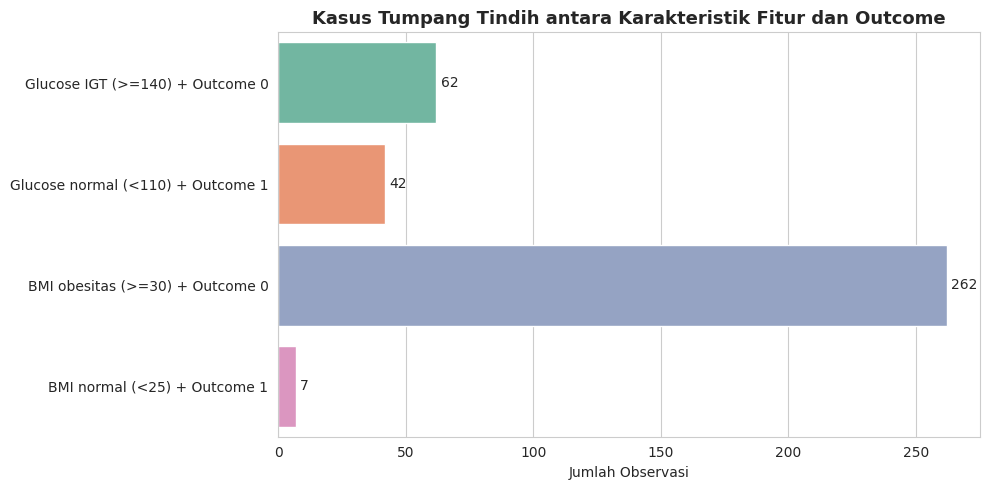

In [83]:
# Visualisasi jenis kasus tidak selaras (mempertahankan visualisasi versi sebelumnya).
plt.figure(figsize=(10, 5))

ax = sns.barplot(data=ringkasan, x='Jumlah', y='Jenis Kasus',
                 hue='Jenis Kasus', palette='Set2', legend=False)

plt.title('Kasus Tumpang Tindih antara Karakteristik Fitur dan Outcome',
          fontsize=13, fontweight='bold')
plt.xlabel('Jumlah Observasi')
plt.ylabel('')

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()


### Interpretasi

Dengan definisi yang konsisten dan ambang yang tepat, gambaran menjadi jauh lebih masuk akal dan informatif.

Kasus **`Glucose` IGT tetapi `Outcome = 0`** dan **BMI obesitas tetapi `Outcome = 0`** tetap berjumlah cukup banyak. Ini **bukan kesalahan data**, melainkan cerminan kenyataan bahwa toleransi glukosa terganggu dan obesitas merupakan **faktor risiko, bukan penentu mutlak** — banyak individu dengan faktor risiko tersebut tidak berlabel diabetes pada dataset ini.

Implikasinya untuk pemodelan: karena kedua kelas saling tumpang tindih pada rentang nilai fitur yang sama, **tidak ada model yang dapat memisahkan kedua kelas secara sempurna**. Inilah alasan mendasar mengapa metrik seperti F1-Score pada dataset ini realistisnya berada di kisaran menengah, bukan mendekati 1,0.


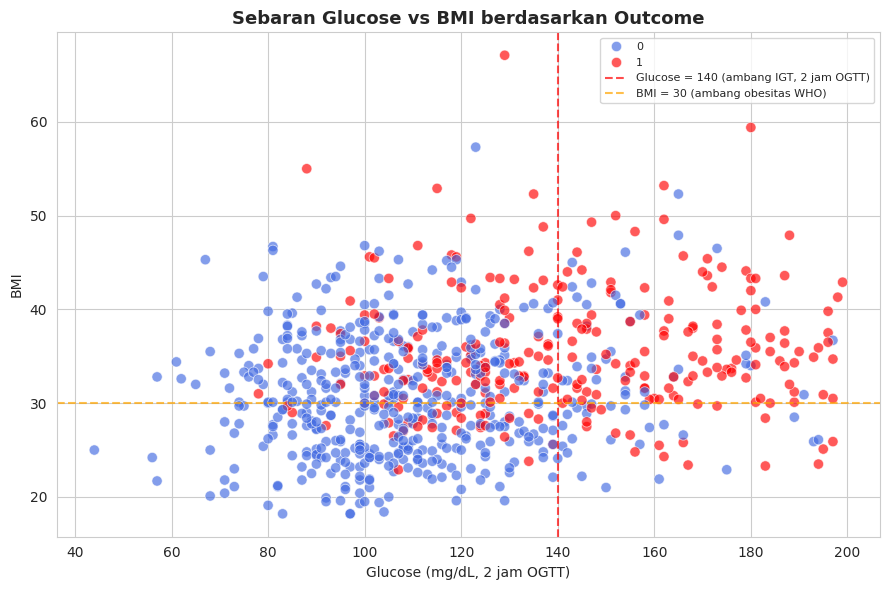

In [84]:
# Visualisasi sebaran Glucose vs BMI dengan garis ambang yang sudah dikoreksi.
plt.figure(figsize=(9, 6))

sns.scatterplot(data=df_overlap, x='Glucose', y='BMI', hue='Outcome',
                palette={0: 'royalblue', 1: 'red'}, s=55, alpha=0.65)

plt.axvline(140, color='red', linestyle='--', alpha=0.7,
            label='Glucose = 140 (ambang IGT, 2 jam OGTT)')
plt.axhline(30, color='orange', linestyle='--', alpha=0.7,
            label='BMI = 30 (ambang obesitas WHO)')

plt.title('Sebaran Glucose vs BMI berdasarkan Outcome', fontsize=13, fontweight='bold')
plt.xlabel('Glucose (mg/dL, 2 jam OGTT)')
plt.ylabel('BMI')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


### Interpretasi

Scatter plot memperlihatkan secara visual apa yang dijelaskan di atas: titik biru (`Outcome = 0`) dan merah (`Outcome = 1`) **bercampur secara substansial**, terutama pada rentang `Glucose` 100–140 dan BMI 25–40.

Pemisahan mulai terlihat pada sisi kanan grafik (`Glucose` tinggi didominasi titik merah), yang konsisten dengan `Glucose` sebagai variabel berkorelasi tertinggi. Namun tidak ada satu garis lurus pun yang dapat memisahkan kedua warna dengan bersih — inilah **batas alamiah performa** yang harus diterima, dan alasan mengapa penambahan kompleksitas model belum tentu banyak membantu.


### KORELASI ANTAR  FITUR

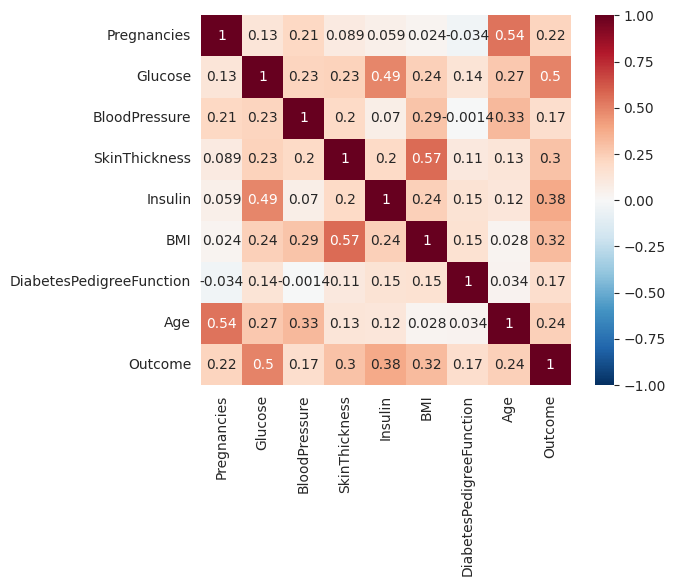

In [85]:
corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    square=True,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0
)

plt.show()

In [86]:
data.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.130155,0.209151,0.089028,0.058767,0.023890,-0.033523,0.544341,0.221898
Glucose,0.130155,1.000000,0.225141,0.229289,0.490015,0.236171,0.138353,0.268910,0.495990
BloodPressure,0.209151,0.225141,1.000000,0.199349,0.070128,0.286399,-0.001443,0.325135,0.174469
SkinThickness,0.089028,0.229289,0.199349,1.000000,0.200129,0.566086,0.106280,0.129537,0.295138
Insulin,0.058767,0.490015,0.070128,0.200129,1.000000,0.238443,0.146878,0.123629,0.377081
BMI,0.023890,0.236171,0.286399,0.566086,0.238443,1.000000,0.152771,0.027849,0.315577
DiabetesPedigreeFunction,-0.033523,0.138353,-0.001443,0.106280,0.146878,0.152771,1.000000,0.033561,0.173844
Age,0.544341,0.268910,0.325135,0.129537,0.123629,0.027849,0.033561,1.000000,0.238356
Outcome,0.221898,0.495990,0.174469,0.295138,0.377081,0.315577,0.173844,0.238356,1.000000


## Analisis Korelasi Antar Variabel

Berdasarkan hasil `data.corr()`, diperoleh nilai korelasi antarvariabel. Nilai korelasi berada pada rentang **-1 hingga 1**.

- Nilai mendekati **1** → hubungan positif yang kuat.
- Nilai mendekati **-1** → hubungan negatif yang kuat.
- Nilai mendekati **0** → hubungan linear yang lemah.

### Korelasi terhadap `Outcome`

Beberapa variabel memiliki korelasi positif terhadap `Outcome`:

| Variabel | Korelasi dengan `Outcome` |
|---|---:|
| `Glucose` | **0.496** |
| `Insulin` | **0.377** |
| `BMI` | **0.316** |
| `SkinThickness` | **0.295** |
| `Age` | **0.238** |
| `Pregnancies` | **0.222** |
| `BloodPressure` | **0.174** |
| `DiabetesPedigreeFunction` | **0.174** |

### Interpretasi

- **`Glucose` memiliki korelasi positif paling tinggi dengan `Outcome`, yaitu 0.496.**
  Hal ini menunjukkan adanya hubungan linear positif yang cukup kuat dibandingkan variabel lainnya. Semakin tinggi nilai `Glucose`, nilai `Outcome` cenderung semakin mengarah ke `1`.

- **`Insulin` memiliki korelasi sebesar 0.377** dengan `Outcome`, menunjukkan hubungan positif dengan `Outcome`.

- **`BMI` memiliki korelasi sebesar 0.316**, menunjukkan hubungan positif dengan `Outcome`.

- **`SkinThickness` memiliki korelasi sebesar 0.295**, menunjukkan hubungan positif dengan `Outcome`.

- **`Age` memiliki korelasi sebesar 0.238**, menunjukkan hubungan positif yang relatif lemah dengan `Outcome`.

- **`Pregnancies` memiliki korelasi sebesar 0.222**, menunjukkan hubungan positif yang relatif lemah dengan `Outcome`.

- **`BloodPressure` dan `DiabetesPedigreeFunction`** masing-masing memiliki korelasi sekitar **0.174**, sehingga hubungan linearnya dengan `Outcome` relatif lemah.

### Korelasi Antar Feature

Selain hubungan dengan `Outcome`, terdapat beberapa korelasi yang cukup terlihat antarvariabel:

- `SkinThickness` dengan `BMI` = **0.566**
- `Glucose` dengan `Insulin` = **0.490**
- `Pregnancies` dengan `Age` = **0.544**
- `BloodPressure` dengan `Age` = **0.325**
- `BloodPressure` dengan `BMI` = **0.286**

Korelasi negatif yang terlihat sangat kecil, misalnya:

- `Pregnancies` dengan `DiabetesPedigreeFunction` = **-0.034**
- `BloodPressure` dengan `DiabetesPedigreeFunction` = **-0.001**

Nilai tersebut mendekati 0, sehingga menunjukkan **hubungan linear yang sangat lemah atau hampir tidak ada**.

## Kesimpulan

Berdasarkan matriks korelasi:

1. **`Glucose` memiliki korelasi paling tinggi dengan `Outcome`**, yaitu **0.496**.
2. `Insulin`, `BMI`, dan `SkinThickness` juga memiliki korelasi positif terhadap `Outcome`.
3. `BloodPressure` dan `DiabetesPedigreeFunction` memiliki korelasi yang relatif lemah terhadap `Outcome`.
4. Korelasi antarvariabel yang cukup tinggi ditemukan pada:
   - `SkinThickness` ↔ `BMI` = **0.566**
   - `Pregnancies` ↔ `Age` = **0.544**
   - `Glucose` ↔ `Insulin` = **0.490**
5. Korelasi menunjukkan **hubungan linear**, bukan hubungan sebab-akibat. Oleh karena itu, nilai korelasi yang tinggi tidak berarti bahwa suatu variabel secara langsung menyebabkan `Outcome = 1`.


> **Catatan tambahan hasil audit (penting).** Seluruh nilai korelasi di atas sudah diverifikasi benar terhadap data. Namun perlu dicatat bahwa korelasi `Insulin` ↔ `Outcome` sebesar **0,377 ikut terpengaruh oleh target leakage** yang ditemukan pada bagian 1b. Jika dihitung hanya dari baris `Insulin` yang terukur asli (tanpa baris hasil imputasi), korelasinya turun menjadi sekitar **0,303**.
>
> Dengan kata lain, posisi `Insulin` sebagai variabel berkorelasi tertinggi kedua **sebagian merupakan artefak imputasi**, bukan sepenuhnya sinyal asli. Korelasi `Glucose` (0,496) tidak terpengaruh karena kolom tersebut praktis tidak mengalami imputasi (hanya 5 nilai 0 pada dataset asli).
>
> Poin ke-5 pada kesimpulan korelasi di atas — bahwa korelasi bukan kausalitas — sudah tepat dan dipertahankan.


In [87]:
data.groupby('Outcome').describe().T

Outcome                     0           1
Pregnancies count  500.000000  268.000000
            mean     3.298000    4.865672
            std      3.017185    3.741239
            min      0.000000    0.000000
            25%      1.000000    1.750000
...                       ...         ...
Age         min     21.000000   21.000000
            25%     23.000000   28.000000
            50%     27.000000   36.000000
            75%     37.000000   44.000000
            max     81.000000   70.000000

[64 rows x 2 columns]

<Axes: >

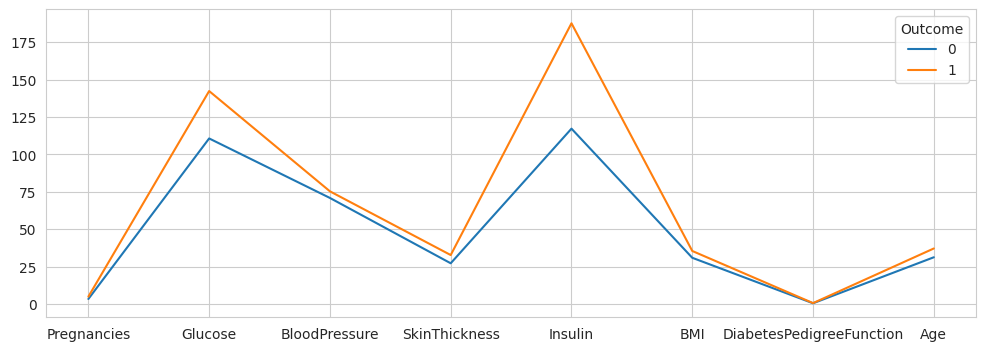

In [88]:
df.groupby('Outcome').mean().T.plot(figsize=(12,4))

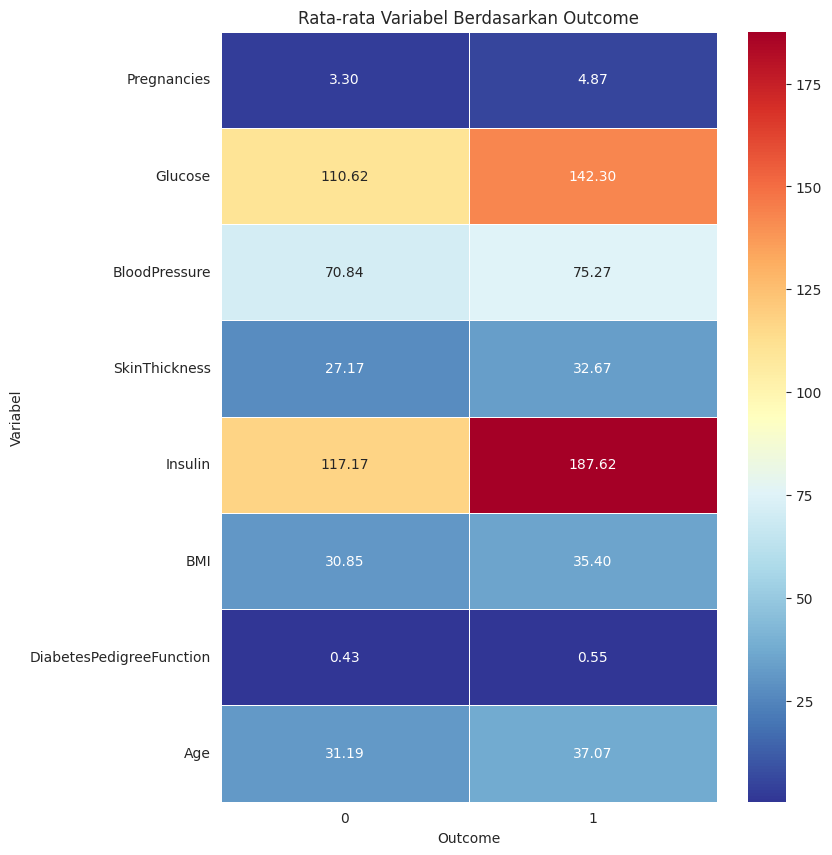

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

mean_outcome = df.groupby('Outcome').mean().T

plt.figure(figsize=(8, 10))

sns.heatmap(
    mean_outcome,
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",
    linewidths=0.5
)

plt.title("Rata-rata Variabel Berdasarkan Outcome")
plt.xlabel("Outcome")
plt.ylabel("Variabel")

plt.show()


### **Interpretasi**

- Besaran **mean** pada kelompok penderita diabetes (`Outcome = 1`) lebih tinggi dibandingkan kelompok non-diabetes (`Outcome = 0`).

- **Variabel yang terlihat berbeda antara `Outcome = 0` dan `Outcome = 1`:**
  - **`Glucose`**: 110,62 → 142,30
  - **`Insulin`**: 117,17 → 187,62
  - **`Pregnancies`**: 3,30 → 4,87
  - **`Age`**: 31,19 → 37,07
  - **`BMI`**: 30,85 → 35,40

  Hal ini menunjukkan bahwa kelompok `Outcome = 1` cenderung memiliki kadar **glukosa, insulin, BMI, usia, dan jumlah kehamilan** yang lebih tinggi dibandingkan kelompok `Outcome = 0`.

- **Hal menarik pada variabel `Insulin`:**
  - Variabel **`Insulin`** memiliki penyebaran yang sangat besar:
    - **Outcome = 0**: minimum 15, maksimum 744
    - **Outcome = 1**: minimum 14, maksimum 846
    - **Standar deviasi**: 75,69 dan 94,11

  Hal ini menunjukkan adanya **nilai ekstrem (outlier)** atau distribusi data yang sangat menyebar. Selain itu, persentil ke-50 dan ke-75 pada `Outcome = 1` sama-sama bernilai **169,5**, yang menunjukkan adanya konsentrasi nilai tertentu pada data dan distribusi yang kemungkinan tidak simetris.


> **Catatan audit atas interpretasi di atas.** Pengamatan bahwa "persentil ke-50 dan ke-75 pada `Outcome = 1` sama-sama bernilai 169,5" adalah **temuan yang sangat tajam dan benar**. Penyebabnya sudah teridentifikasi pada bagian 1b: nilai tersebut adalah hasil **imputasi median per kelompok target**, bukan sekadar "konsentrasi nilai tertentu".
>
> Karena itu, angka mean `Insulin` yang dikutip (117,17 vs 187,62) dihitung dari data yang sudah tercemar imputasi dan sebaiknya tidak dijadikan dasar kesimpulan kuantitatif.


### Interpretasi Insulin

Menariknya, rata-rata `Insulin` pada kelompok `Outcome = 1` (187.62) lebih tinggi dibandingkan `Outcome = 0` (117.17).

Hal ini dapat berkaitan dengan kondisi **resistensi insulin**, di mana tubuh masih memproduksi insulin, tetapi sel tubuh kurang responsif terhadap insulin tersebut. Akibatnya, tubuh dapat meningkatkan produksi insulin untuk membantu mengontrol kadar glukosa.

Namun, hasil ini hanya menunjukkan **perbedaan secara deskriptif** dan tidak dapat digunakan untuk menyimpulkan hubungan sebab-akibat. Selain itu, variabel `Insulin` memiliki beberapa nilai ekstrem sehingga perlu dilakukan pemeriksaan lebih lanjut.


> **Catatan audit.** Penjelasan mengenai resistensi insulin di atas **tetap valid secara substansi**, dan pembatasan bahwa hasil ini tidak menunjukkan sebab-akibat sudah tepat.
>
> Sebagai verifikasi, selisih rata-rata `Insulin` antar kelompok dihitung ulang hanya dari 394 baris yang terukur asli: **130,29 (`Outcome = 0`) vs 206,85 (`Outcome = 1`)**, dengan selisih 76,56 — bahkan sedikit lebih besar daripada selisih pada data penuh (70,44). Jadi perbedaan kadar insulin antar kelompok **benar-benar ada pada data asli**, bukan semata artefak imputasi. Yang menggelembung karena imputasi adalah **nilai korelasinya**, bukan arah temuannya.


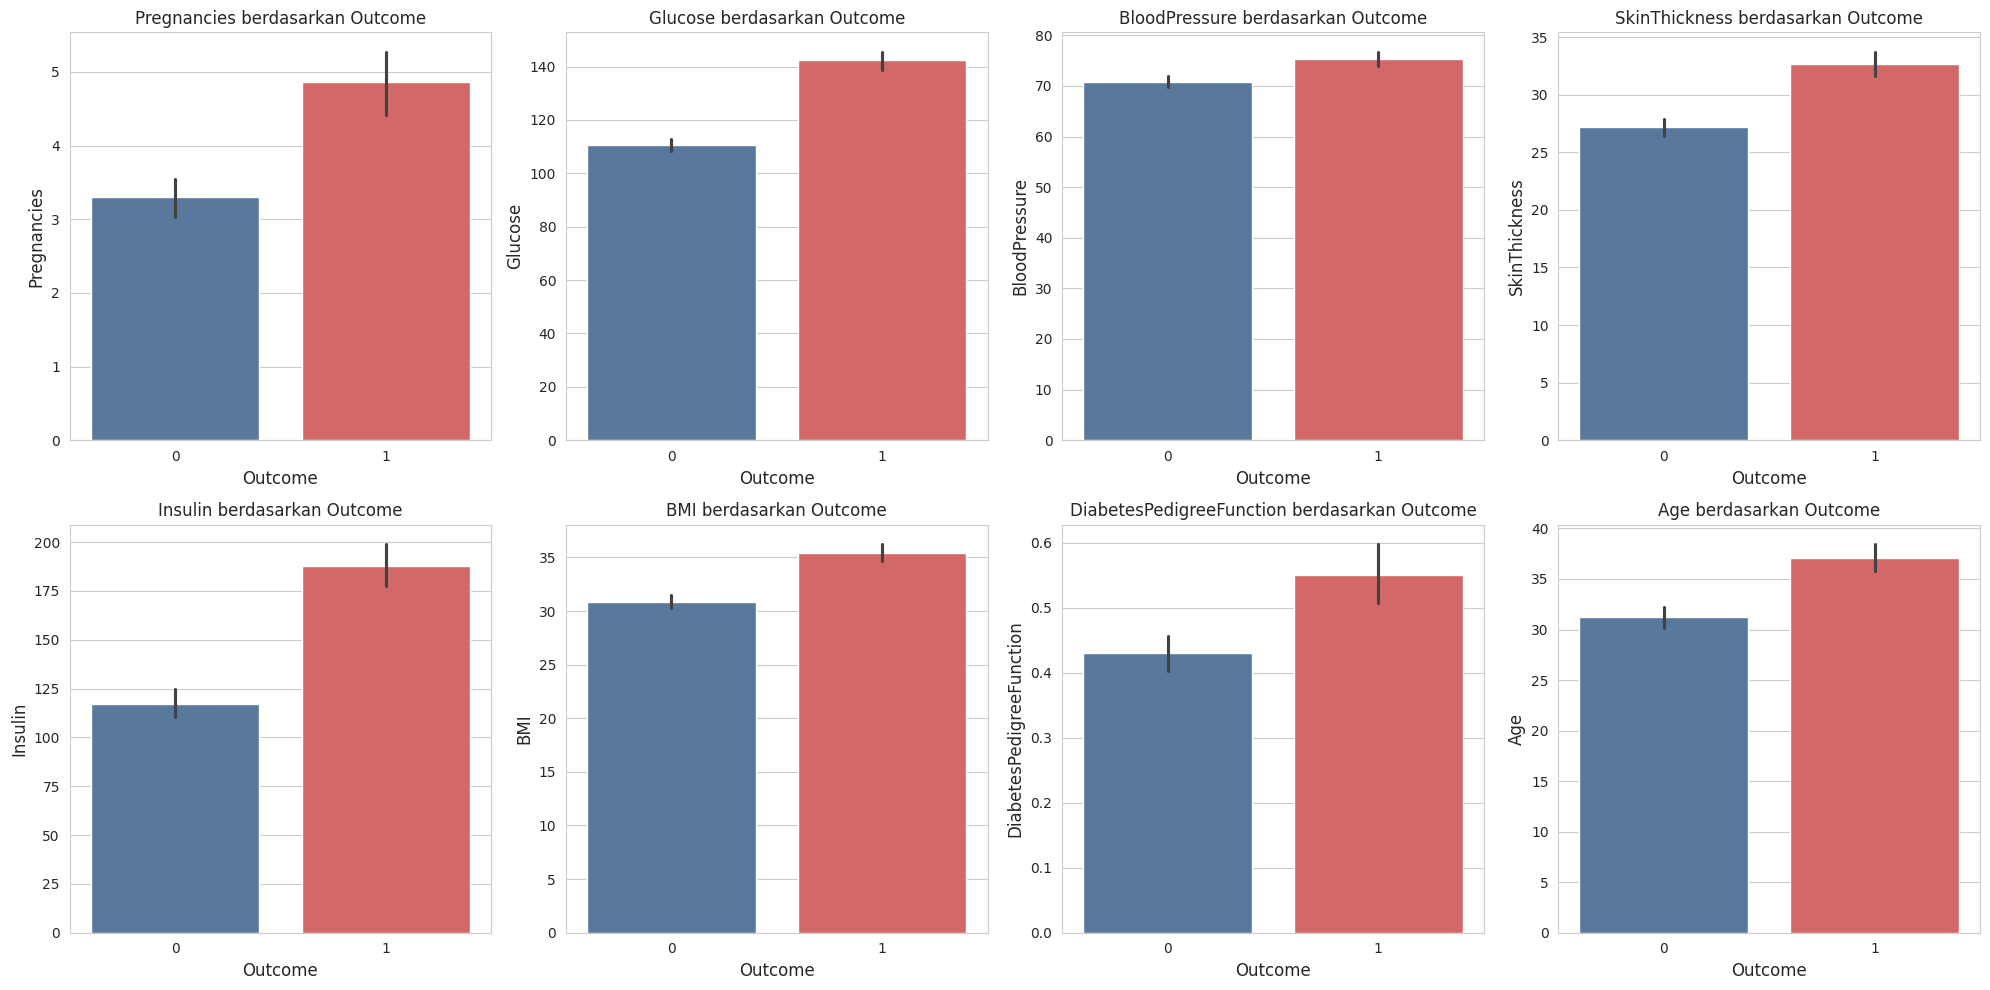

In [90]:
#relation between each feature and the outcome variable by barplot..
plt.figure(figsize=(20, 10))

features = [col for col in df.columns if col != 'Outcome']

for i, col in enumerate(features):
    plt.subplot(2, 4, i + 1)

    sns.barplot(
        data=df,
        x='Outcome',
        y=col,
        hue='Outcome',
        palette={0: '#4C78A8', 1: '#E45756'},
        legend=False
    )

    plt.xlabel('Outcome', fontsize=12)
    plt.ylabel(col, fontsize=12)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.title(f'{col} berdasarkan Outcome')

plt.tight_layout()
plt.show()

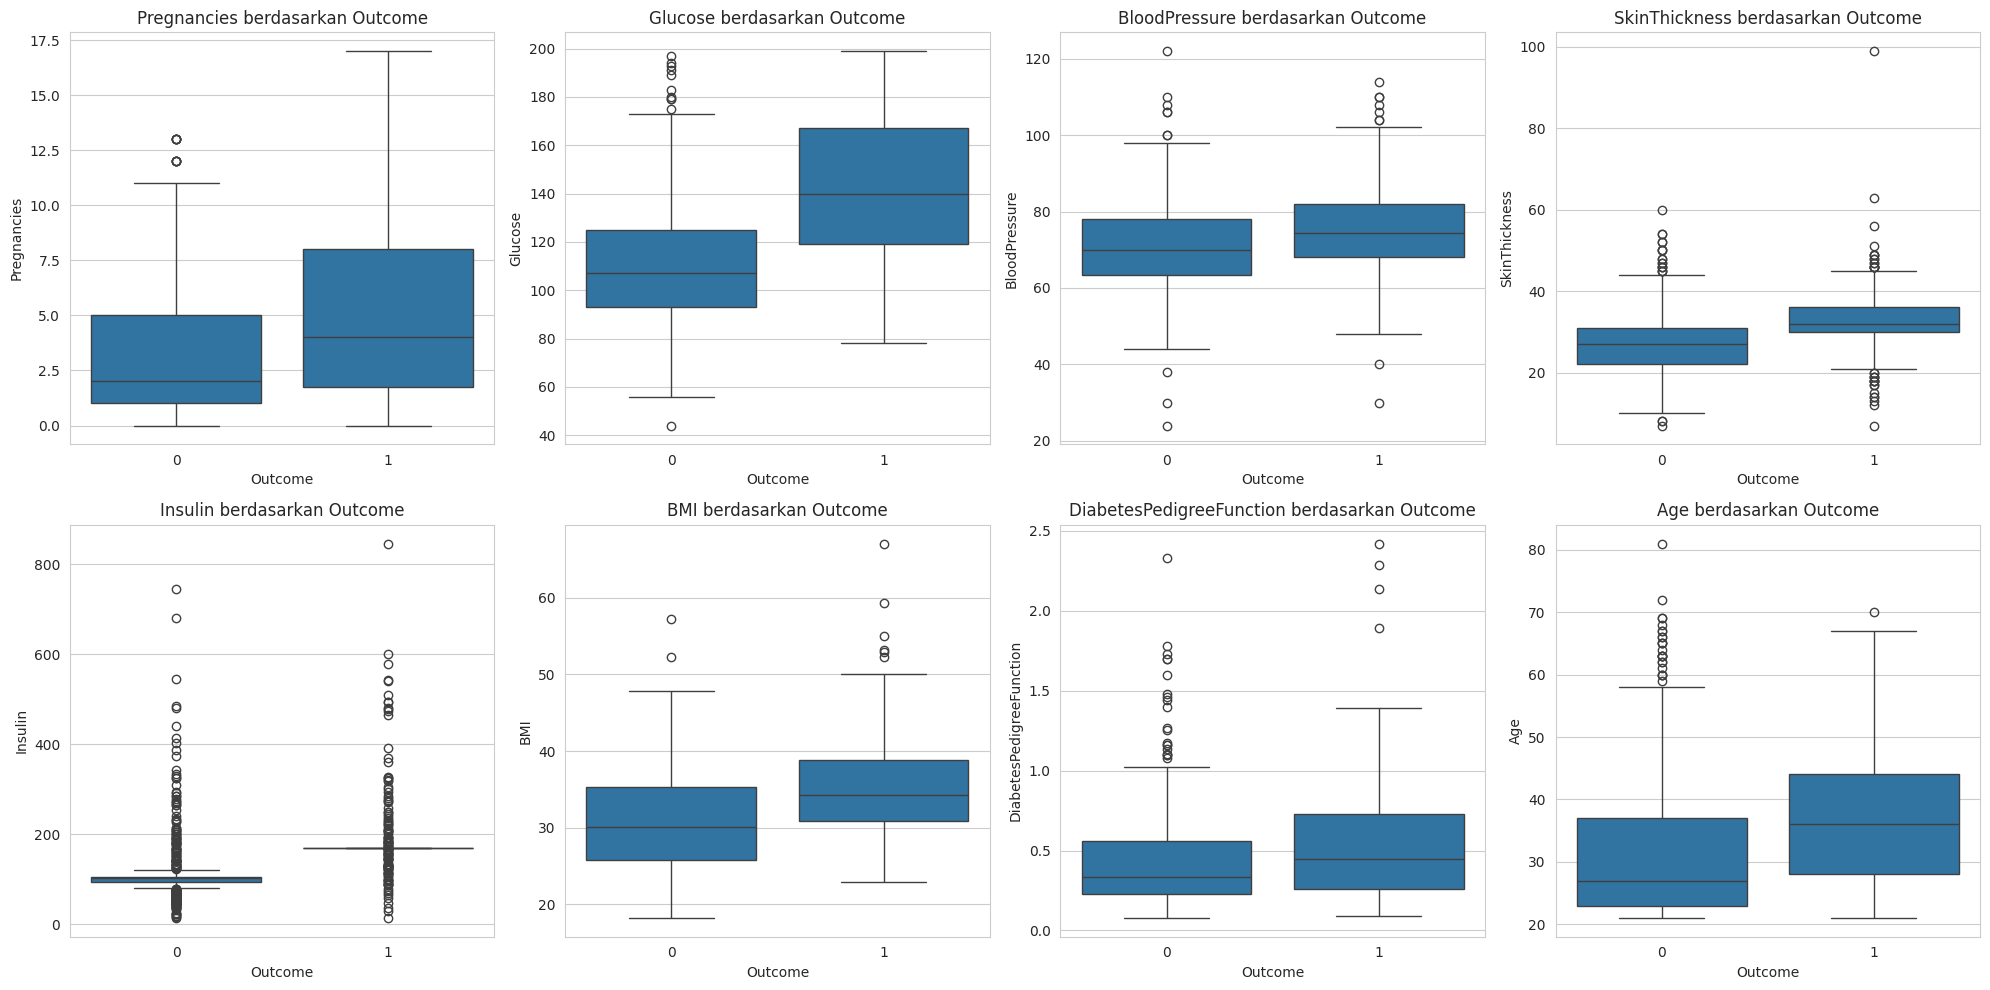

In [91]:
plt.figure(figsize=(20, 10))

for i, col in enumerate(data.columns.drop('Outcome')):
    plt.subplot(2, 4, i + 1)
    sns.boxplot(data=data, x='Outcome', y=col)
    plt.title(f'{col} berdasarkan Outcome')
    plt.xlabel('Outcome')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

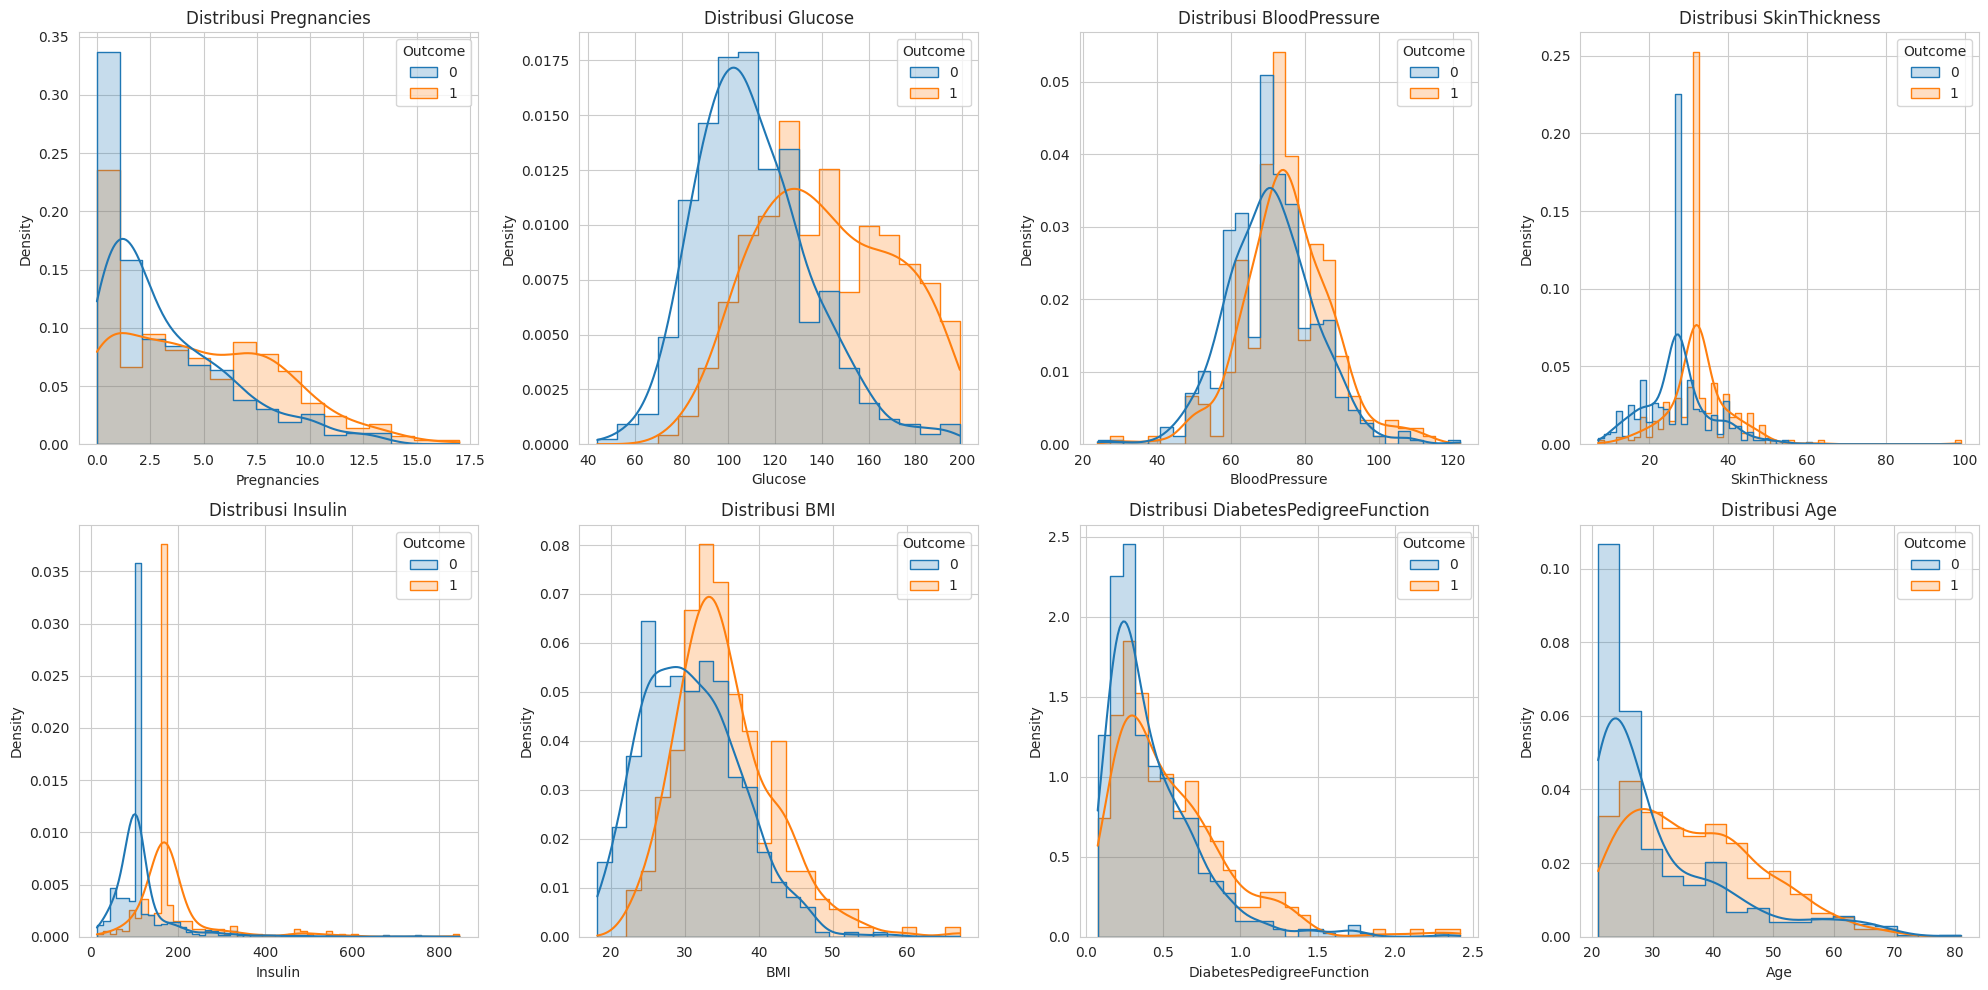

In [92]:
plt.figure(figsize=(20, 10))

for i, col in enumerate(data.columns.drop('Outcome')):
    plt.subplot(2, 4, i + 1)
    sns.histplot(
        data=data,
        x=col,
        hue='Outcome',
        kde=True,
        element='step',
        stat='density',
        common_norm=False
    )
    plt.title(f'Distribusi {col}')
    
plt.tight_layout()
plt.show()

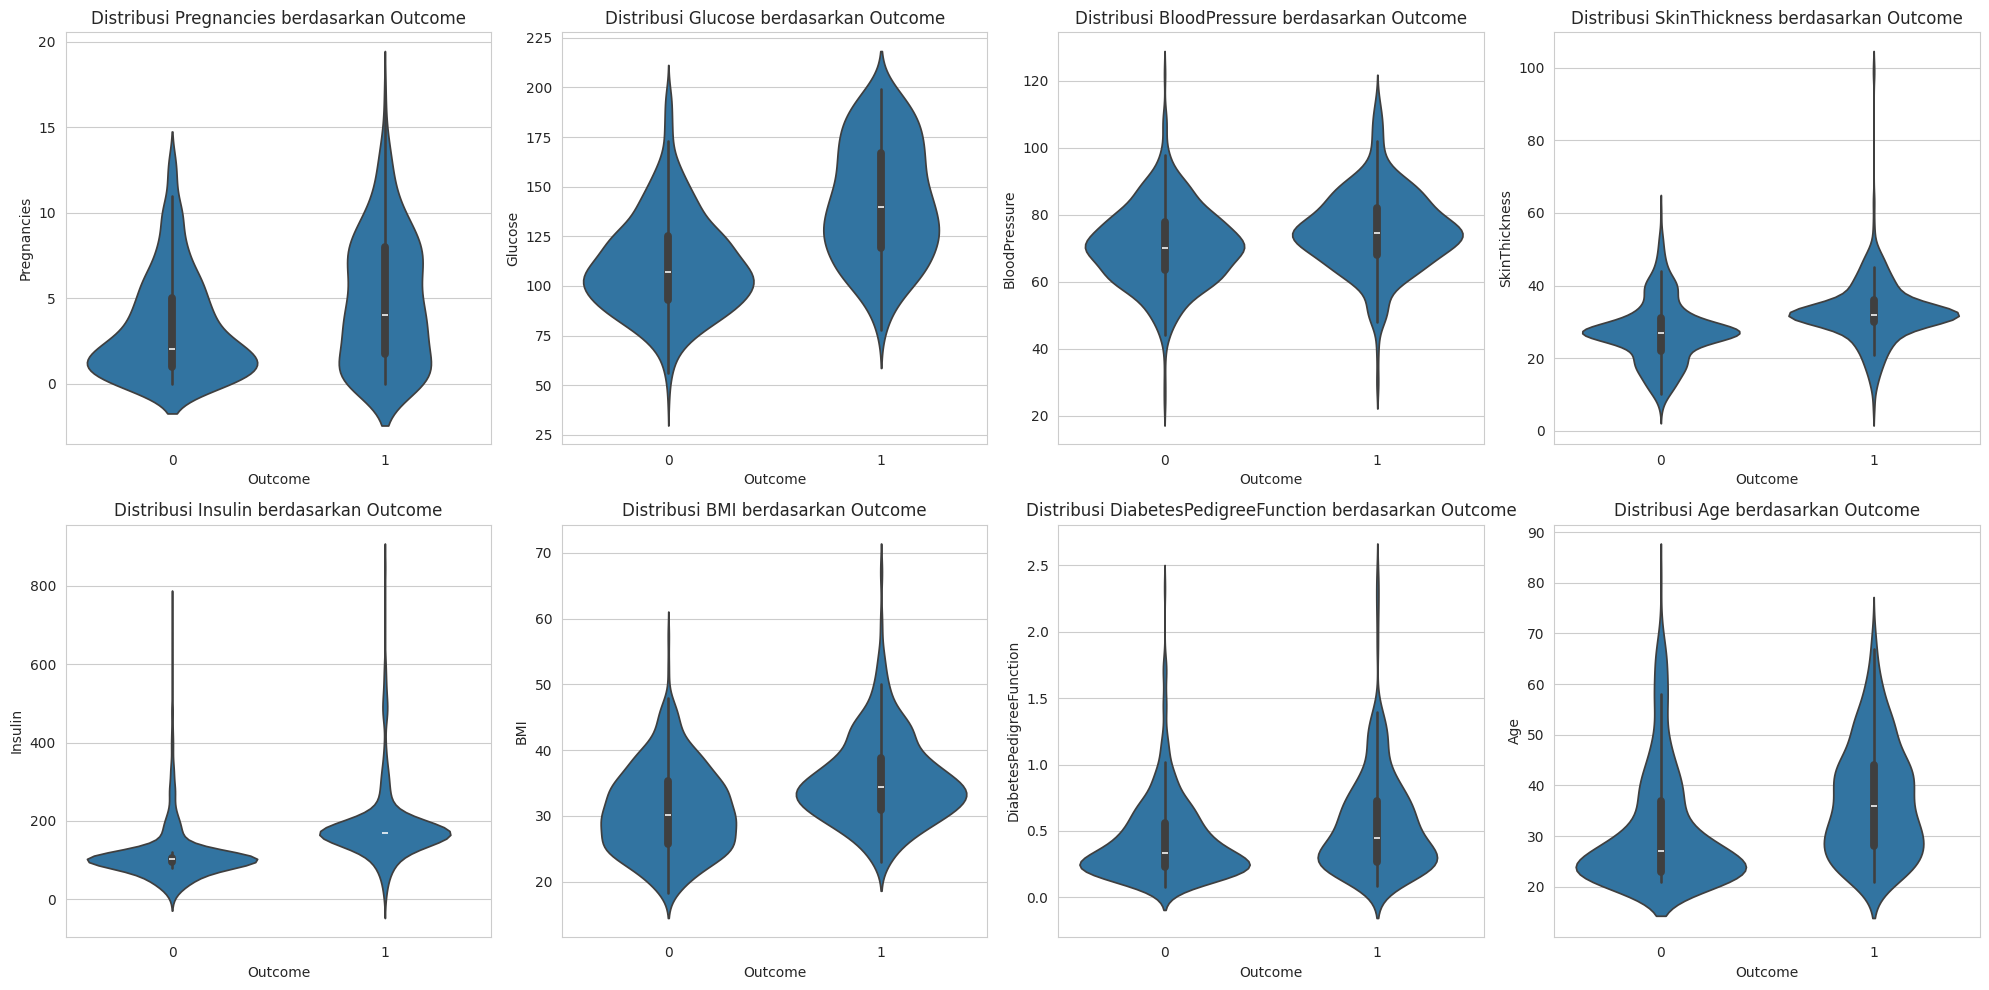

In [93]:
plt.figure(figsize=(20, 10))

for i, col in enumerate(data.columns.drop('Outcome')):
    plt.subplot(2, 4, i + 1)
    sns.violinplot(data=data, x='Outcome', y=col)
    plt.title(f'Distribusi {col} berdasarkan Outcome')
    plt.xlabel('Outcome')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

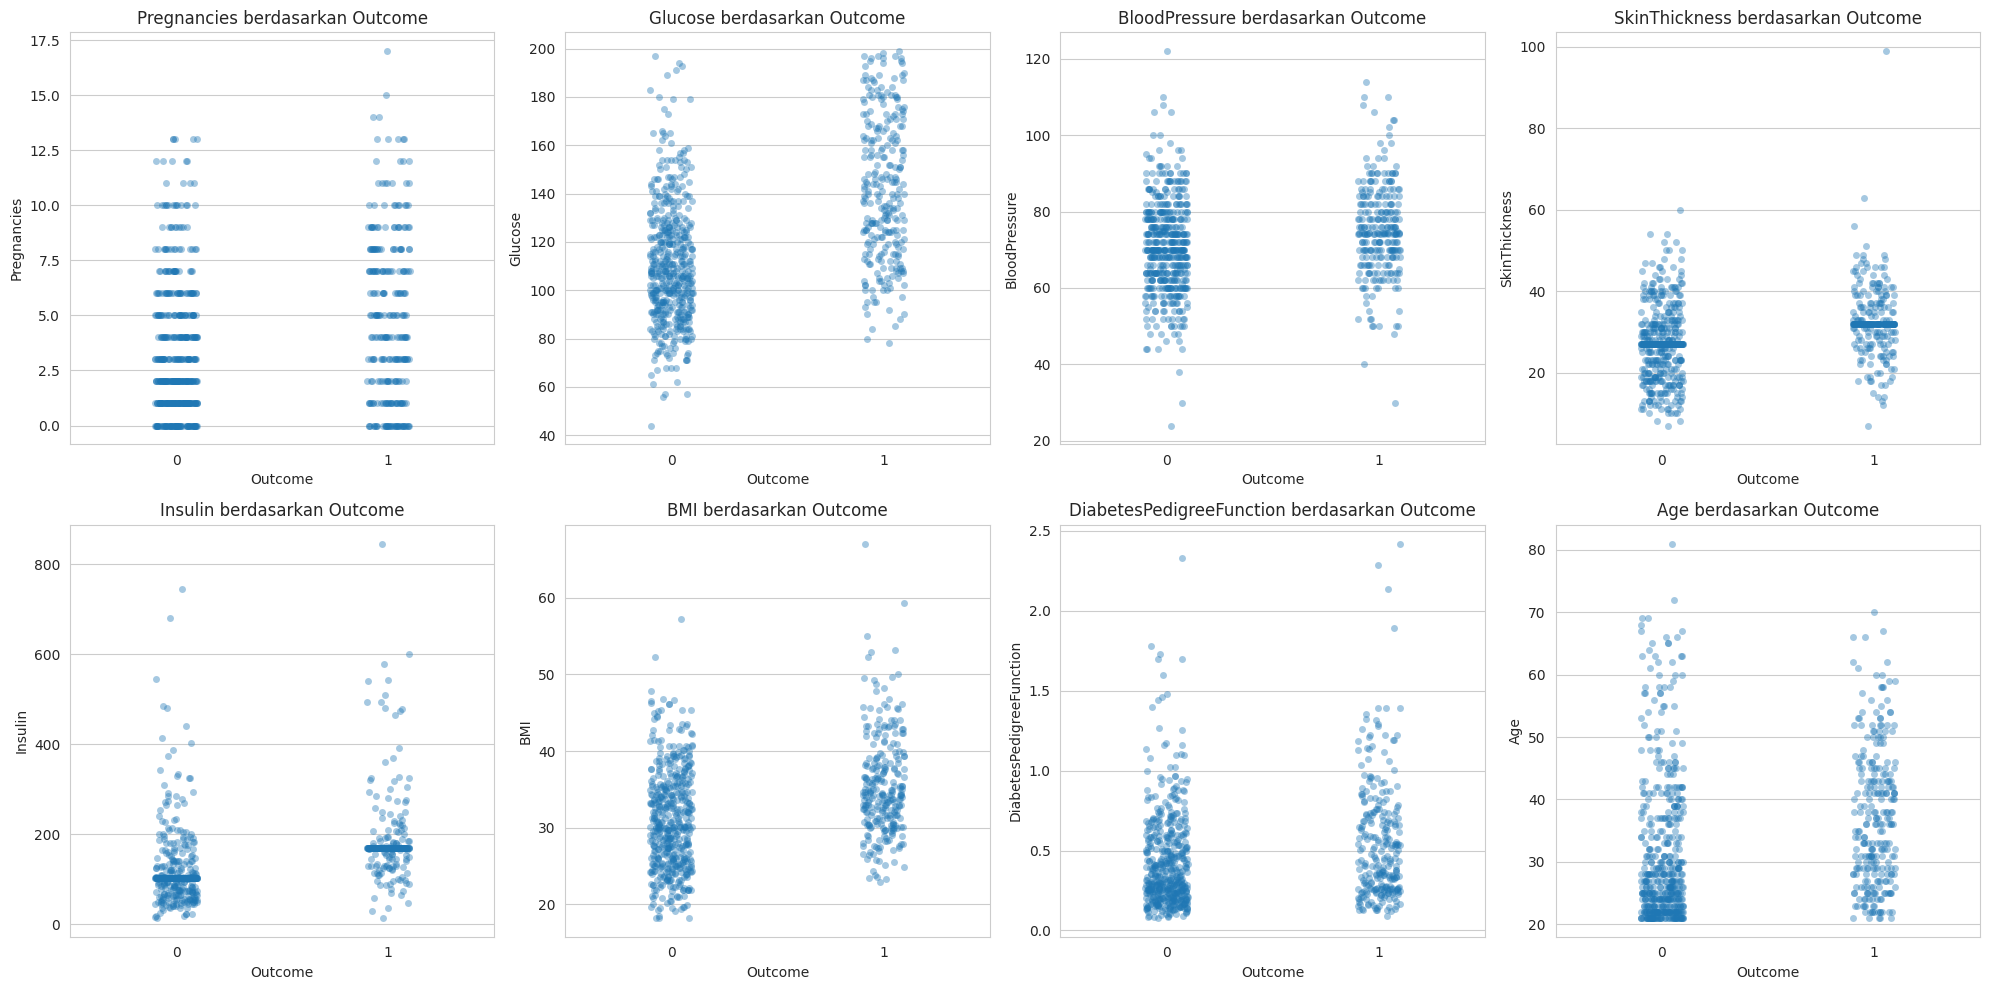

In [94]:
plt.figure(figsize=(20, 10))

for i, col in enumerate(data.columns.drop('Outcome')):
    plt.subplot(2, 4, i + 1)
    sns.stripplot(data=data, x='Outcome', y=col, alpha=0.4)
    plt.title(f'{col} berdasarkan Outcome')
    plt.xlabel('Outcome')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

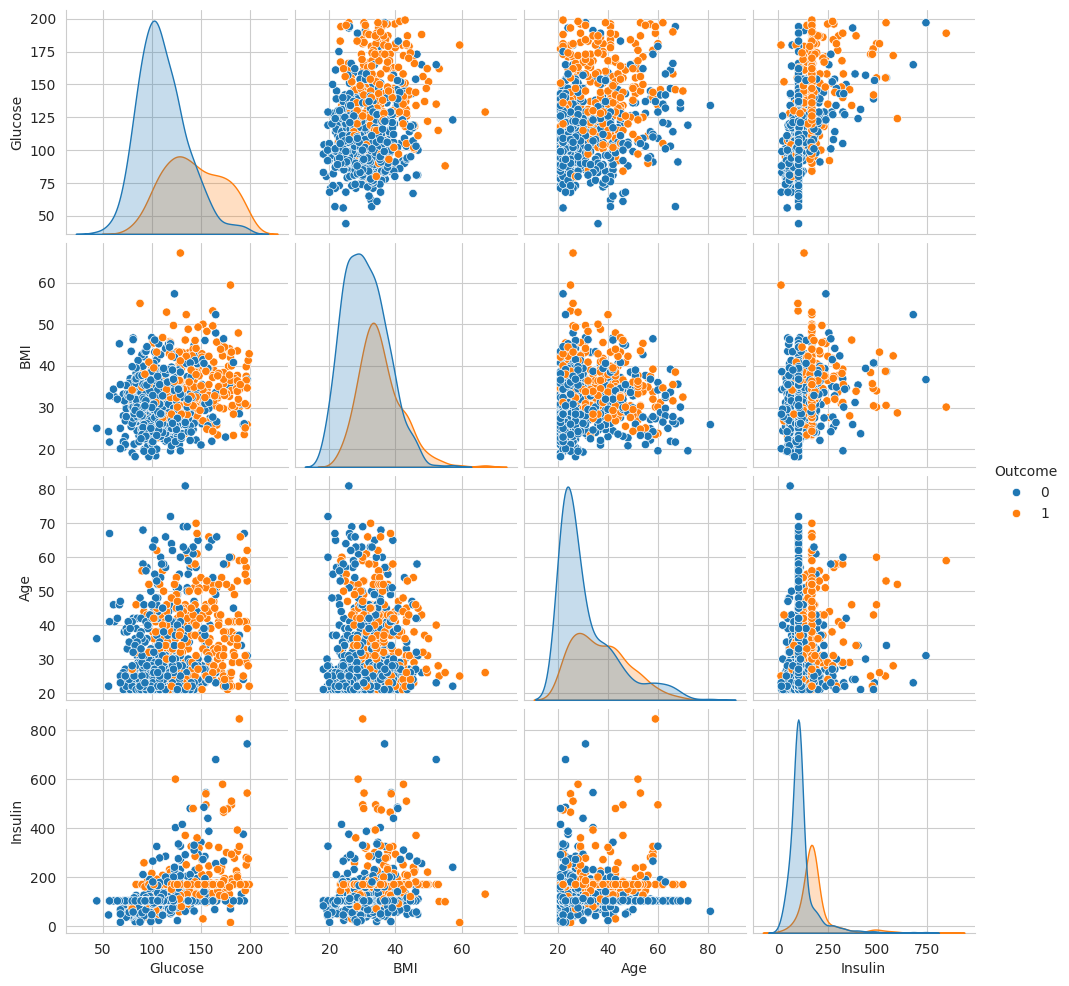

In [95]:
sns.pairplot(
    data[['Glucose', 'BMI', 'Age', 'Insulin', 'Outcome']],
    hue='Outcome',
    diag_kind='kde'
)

plt.show()

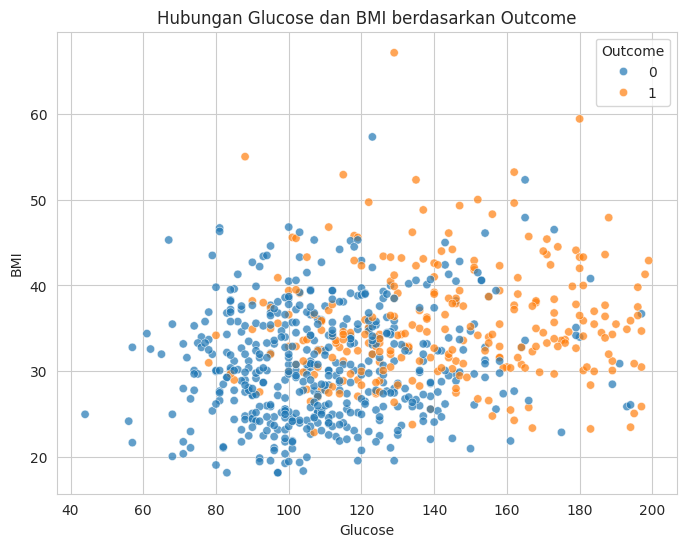

In [96]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=data,
    x='Glucose',
    y='BMI',
    hue='Outcome',
    alpha=0.7
)

plt.title('Hubungan Glucose dan BMI berdasarkan Outcome')
plt.show()

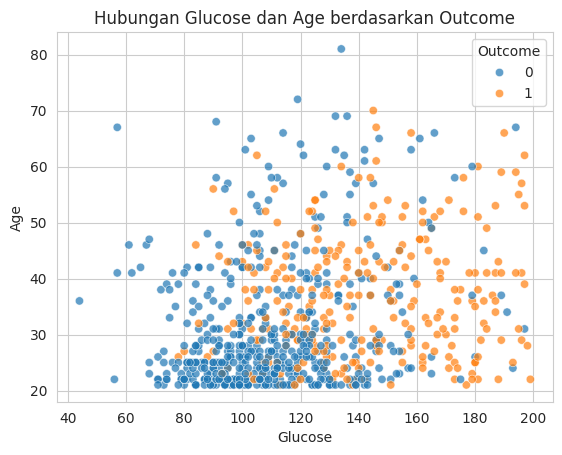

In [97]:
sns.scatterplot(
    data=data,
    x='Glucose',
    y='Age',
    hue='Outcome',
    alpha=0.7
)

plt.title('Hubungan Glucose dan Age berdasarkan Outcome')
plt.show()

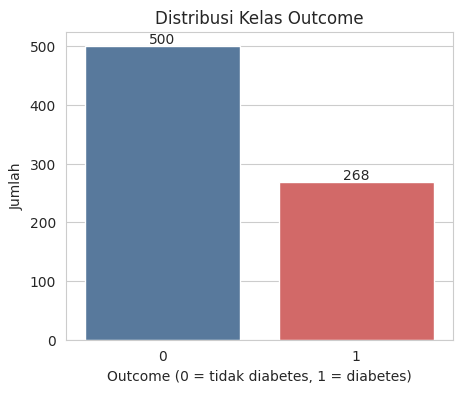

Outcome
0    500
1    268
Name: count, dtype: int64
Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64


In [98]:
# PERBAIKAN: placeholder diisi.
# Distribusi kelas target (Outcome).
plt.figure(figsize=(5, 4))
ax = sns.countplot(data=df, x='Outcome', hue='Outcome',
                   palette={0: '#4C78A8', 1: '#E45756'}, legend=False)
for c in ax.containers:
    ax.bar_label(c)
plt.title('Distribusi Kelas Outcome')
plt.xlabel('Outcome (0 = tidak diabetes, 1 = diabetes)')
plt.ylabel('Jumlah')
plt.show()

print(df['Outcome'].value_counts())
print(df['Outcome'].value_counts(normalize=True).round(3))


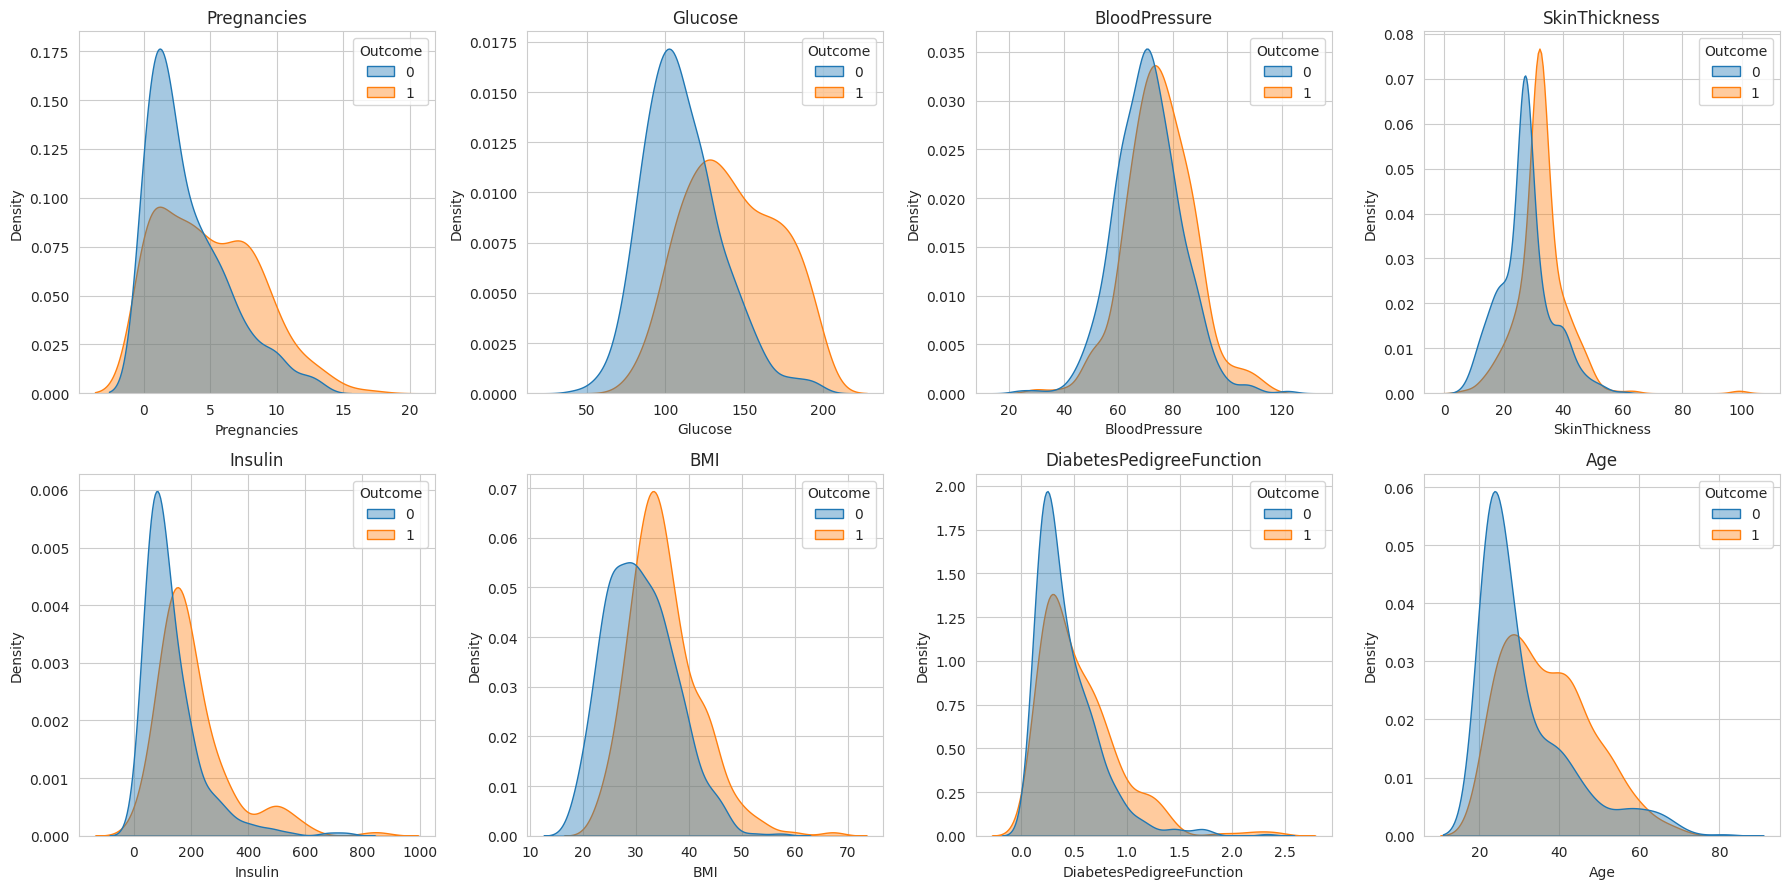

In [99]:
# PERBAIKAN: placeholder diisi.
# Distribusi setiap fitur, dibedakan berdasarkan Outcome (memakai data hasil
# pembersihan leakage agar tidak menampilkan puncak buatan hasil imputasi).
fitur = [c for c in df_clean.columns if c != 'Outcome']

plt.figure(figsize=(18, 9))
for i, col in enumerate(fitur):
    plt.subplot(2, 4, i + 1)
    sns.kdeplot(data=df_clean, x=col, hue='Outcome',
                fill=True, common_norm=False, alpha=0.4)
    plt.title(col)
plt.tight_layout()
plt.show()


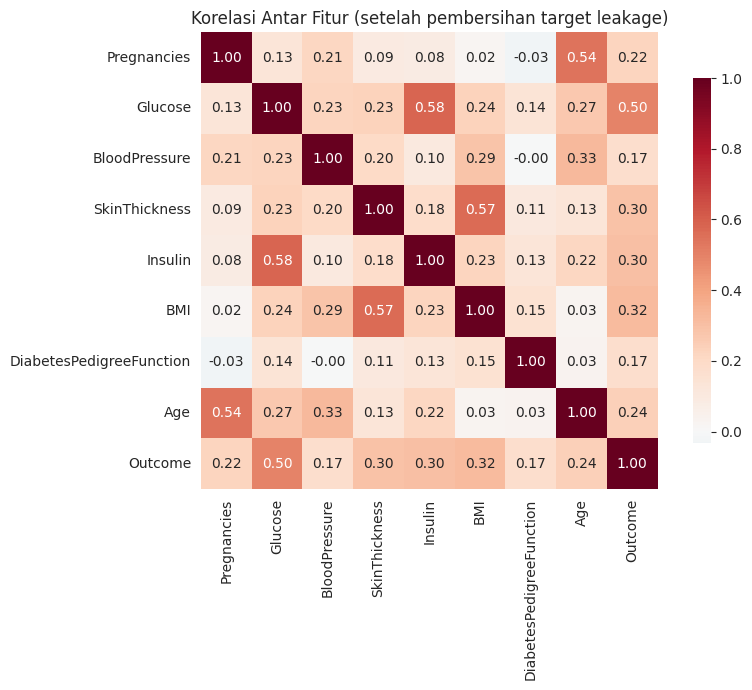

Korelasi terhadap Outcome:
Glucose                     0.496
BMI                         0.316
Insulin                     0.303
SkinThickness               0.295
Age                         0.238
Pregnancies                 0.222
DiabetesPedigreeFunction    0.174
BloodPressure               0.173
Name: Outcome, dtype: float64


In [100]:
# PERBAIKAN: placeholder diisi.
# Heatmap korelasi setelah pembersihan leakage, untuk dibandingkan dengan
# heatmap sebelumnya yang masih memuat nilai hasil imputasi.
plt.figure(figsize=(9, 7))
sns.heatmap(df_clean.corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, cbar_kws={'shrink': 0.8})
plt.title('Korelasi Antar Fitur (setelah pembersihan target leakage)')
plt.tight_layout()
plt.show()

print('Korelasi terhadap Outcome:')
print(df_clean.corr()['Outcome'].drop('Outcome').sort_values(ascending=False).round(3))


## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

### Interpretasi EDA Tambahan

Heatmap korelasi yang dihitung setelah pembersihan *target leakage* memperlihatkan perubahan penting: **korelasi `Insulin` terhadap `Outcome` turun** dibandingkan perhitungan pada data awal. Ini menegaskan kembali bahwa sebagian kekuatan hubungan `Insulin` sebelumnya berasal dari nilai imputasi berbasis target, bukan dari pengukuran asli.

Sementara itu, `Glucose` tetap menjadi variabel dengan korelasi tertinggi terhadap `Outcome` dan nilainya praktis tidak berubah, sehingga temuan tersebut dapat dianggap **robust**.


# 2. Preprocessing

## 2.1 Strategi Penanganan Missing Value

Berdasarkan temuan pada bagian 1b, nilai hasil imputasi berbasis target sudah dikembalikan menjadi `NaN` pada `df_clean`. Nilai tersebut kini akan diimputasi ulang dengan cara yang benar, mengikuti dua prinsip:

1. **Tanpa menggunakan variabel target.** Imputasi hanya boleh memakai informasi dari fitur, tidak boleh melihat `Outcome` — justru inilah kesalahan yang menyebabkan kebocoran pada dataset asli.
2. **Hanya berdasarkan data train.** Imputasi dibungkus dalam `Pipeline`, sehingga nilai median dihitung ulang di setiap fold/split **hanya dari data train**, lalu diterapkan ke data test. Dengan demikian tidak ada informasi dari test set yang bocor ke proses pelatihan.


In [101]:
# PERBAIKAN:
# Memeriksa kembali nilai 0 yang secara medis tidak valid pada df_clean.
cols_cek = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

zero_summary = pd.DataFrame({
    'Jumlah Nilai 0': (df_clean[cols_cek] == 0).sum(),
    'Jumlah NaN (hasil pemulihan)': df_clean[cols_cek].isna().sum()
})
display(zero_summary)

print('Jumlah baris duplikat:', df_clean.duplicated().sum())


,Jumlah Nilai 0,Jumlah NaN (hasil pemulihan)
Glucose,0,0
BloodPressure,0,16
SkinThickness,0,0
Insulin,0,374
BMI,0,0


Jumlah baris duplikat: 0


### Interpretasi

Tidak ditemukan nilai `0` yang tersisa pada kelima kolom tersebut, karena penyedia dataset memang sudah menggantinya — sayangnya dengan metode yang menimbulkan kebocoran. Kolom `NaN` pada tabel di atas menunjukkan nilai yang berhasil dipulihkan kembali menjadi *missing* untuk diimputasi ulang secara benar.

Pemeriksaan duplikat juga dilakukan karena baris duplikat dapat muncul di train dan test sekaligus. Hasilnya **0 duplikat**, sehingga tidak diperlukan tindakan lanjutan.


## 2.2 Pemeriksaan Outlier

In [102]:
# Identifikasi outlier dengan metode IQR (tanpa penghapusan otomatis).
outlier_cols = ['Glucose', 'SkinThickness', 'Insulin', 'BMI']
rep = {}

for col in outlier_cols:
    Q1, Q3 = df_clean[col].quantile(0.25), df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    low, up = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n = ((df_clean[col] < low) | (df_clean[col] > up)).sum()
    rep[col] = {'Q1': Q1, 'Q3': Q3, 'Batas Bawah': round(low, 2),
                'Batas Atas': round(up, 2), 'Jumlah Outlier': n,
                'Persentase (%)': round(n / len(df_clean) * 100, 2)}

display(pd.DataFrame(rep).T)


,Q1,Q3,Batas Bawah,Batas Atas,Jumlah Outlier,Persentase (%)
Glucose,99.75,140.25,39.00,201.00,0.0,0.00
SkinThickness,25.00,32.00,14.50,42.50,87.0,11.33
Insulin,76.25,190.00,-94.38,360.62,24.0,3.12
BMI,27.50,36.60,13.85,50.25,8.0,1.04


### Interpretasi

Outlier **tidak dihapus**, dengan alasan berikut:

1. Pada data medis, nilai ekstrem umumnya merepresentasikan **kondisi klinis nyata** (misalnya resistensi insulin berat), bukan kesalahan pencatatan.
2. Menghapusnya akan mengurangi jumlah data yang sudah terbatas (768 baris) dan membuang justru kasus yang informatif.
3. Menghapus observasi yang "tidak sesuai ekspektasi" akan menaikkan metrik secara semu — persis kekeliruan yang sudah dibahas pada bagian 1c.1.

Sebagai gantinya, `StandardScaler` digunakan untuk menyetarakan skala antar fitur.


## 2.3 Train-Test Split

In [103]:
# PERBAIKAN:
# Menggunakan df_clean (sudah bebas dari target leakage yang dapat diidentifikasi),
# dengan stratify=y karena distribusi kelas tidak seimbang (65:35).

X = df_clean.drop(columns='Outcome')
y = df_clean['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print('X_train:', X_train.shape, '| X_test:', X_test.shape)
print()
print('Proporsi Outcome pada y_train:'); print(y_train.value_counts(normalize=True).round(4))
print()
print('Proporsi Outcome pada y_test :'); print(y_test.value_counts(normalize=True).round(4))
print()
print('Missing value pada X_train:', X_train.isna().sum().sum(),
      '| pada X_test:', X_test.isna().sum().sum())


X_train: (614, 8) | X_test: (154, 8)

Proporsi Outcome pada y_train:
Outcome
0    0.6515
1    0.3485
Name: proportion, dtype: float64

Proporsi Outcome pada y_test :
Outcome
0    0.6494
1    0.3506
Name: proportion, dtype: float64

Missing value pada X_train: 301 | pada X_test: 89


### Interpretasi

Proporsi kelas pada train (65,15% : 34,85%) dan test (64,94% : 35,06%) hampir identik dengan proporsi populasi awal (65,1% : 34,9%), sehingga stratifikasi bekerja sebagaimana mestinya.

Perhatikan bahwa masih terdapat *missing value* pada kedua himpunan. Nilai ini **sengaja tidak diimputasi di sini**, melainkan di dalam `Pipeline` pada tahap berikutnya, agar median dihitung hanya dari data train.


## 2.4 Pipeline Preprocessing

`Pipeline` digunakan agar imputasi dan penskalaan **selalu dipelajari ulang dari data train saja**, baik pada satu kali split maupun pada setiap fold cross-validation. Ini mencegah data leakage secara struktural, bukan hanya mengandalkan urutan penulisan kode.


In [104]:
# PERBAIKAN:
# Imputasi median + StandardScaler dibungkus Pipeline bersama model,
# sehingga tidak ada informasi test set yang bocor ke proses training.

def buat_pipeline(model):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('clf', model)
    ])

print(buat_pipeline(GaussianNB()))


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()), ('clf', GaussianNB())])


# 3. Eksperimen Model

## 3.1 Gaussian Naive Bayes

Digunakan **Gaussian** Naive Bayes karena seluruh fitur bersifat numerik kontinu, sehingga varian Gaussian adalah pilihan yang sesuai (berbeda dengan MultinomialNB yang ditujukan untuk data hitungan/diskret).

**Asumsi dasar Naive Bayes** yang perlu disadari:

1. **Conditional independence**: setiap fitur dianggap saling bebas jika kelasnya diketahui. Pada dataset ini asumsi tersebut **jelas tidak sepenuhnya terpenuhi** — misalnya `SkinThickness` dan `BMI` berkorelasi 0,566, serta `Pregnancies` dan `Age` berkorelasi 0,544.
2. **Normalitas per kelas**: setiap fitur diasumsikan berdistribusi normal pada masing-masing kelas.

Sesuai ketentuan tugas, model **tidak diganti** meskipun asumsi ini tidak ideal. Naive Bayes memang dikenal tetap bekerja cukup baik dalam praktik walau asumsinya dilanggar; hal ini justru menjadi bahan pembahasan pada bagian analisis.


In [105]:
# Inisialisasi dan latih Gaussian Naive Bayes (imputasi & scaling di dalam Pipeline).
nb_model = buat_pipeline(GaussianNB())
nb_model.fit(X_train, y_train)


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()), ('clf', GaussianNB())])

In [106]:
# Prediksi pada test set: label dan probabilitas kelas 1.
nb_pred = nb_model.predict(X_test)
nb_proba = nb_model.predict_proba(X_test)[:, 1]

print('10 prediksi pertama :', nb_pred[:10])
print('10 probabilitas awal:', np.round(nb_proba[:10], 3))


10 prediksi pertama : [0 0 0 0 0 0 1 1 0 1]
10 probabilitas awal: [0.47  0.325 0.179 0.121 0.008 0.039 0.778 0.996 0.008 0.991]


## 3.2 Logistic Regression

In [107]:
# Inisialisasi dan latih Logistic Regression.
lr_model = buat_pipeline(LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
lr_model.fit(X_train, y_train)


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('clf', LogisticRegression(max_iter=1000, random_state=42))])

In [108]:
# Prediksi pada test set: label dan probabilitas kelas 1.
lr_pred = lr_model.predict(X_test)
lr_proba = lr_model.predict_proba(X_test)[:, 1]

print('10 prediksi pertama :', lr_pred[:10])
print('10 probabilitas awal:', np.round(lr_proba[:10], 3))


10 prediksi pertama : [1 0 0 0 0 0 0 1 0 1]
10 probabilitas awal: [0.609 0.092 0.263 0.283 0.026 0.143 0.48  0.935 0.072 0.853]


### Interpretasi

Kedua model dilatih memakai **train-test split, pipeline preprocessing, dan `random_state` yang sama persis**, sehingga perbandingan keduanya bersifat adil (*fair comparison*) dan perbedaan hasil yang muncul benar-benar berasal dari karakteristik algoritmanya, bukan dari perbedaan perlakuan data.


# 4. Evaluasi Model

In [109]:
# Metrik evaluasi kedua model pada test set.
def hitung_metrik(nama, y_true, y_pred, y_proba):
    return {
        'Model': nama,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_proba)
    }

hasil = pd.DataFrame([
    hitung_metrik('Gaussian Naive Bayes', y_test, nb_pred, nb_proba),
    hitung_metrik('Logistic Regression', y_test, lr_pred, lr_proba)
]).set_index('Model').round(4)

display(hasil)


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Gaussian Naive Bayes,0.7078,0.5763,0.6296,0.6018,0.7737
Logistic Regression,0.6948,0.5745,0.5000,0.5347,0.8180


### Interpretasi

Pada test set (154 observasi), kedua model menunjukkan **trade-off yang jelas**:

- **Gaussian Naive Bayes** memperoleh Recall lebih tinggi (0,630 vs 0,500) dan F1-Score lebih tinggi (0,602 vs 0,535).
- **Logistic Regression** memperoleh ROC-AUC lebih tinggi (0,818 vs 0,774).

Artinya, Naive Bayes lebih banyak mengenali observasi berlabel diabetes, sedangkan Logistic Regression lebih baik dalam mengurutkan observasi berdasarkan probabilitas secara keseluruhan (yang diukur ROC-AUC pada semua kemungkinan threshold).

Tidak ada model yang unggul pada semua metrik, sehingga **belum dapat disimpulkan satu model "lebih baik"** hanya dari tabel ini. Perbandingan yang lebih stabil dilakukan melalui cross-validation di bagian 4.3.


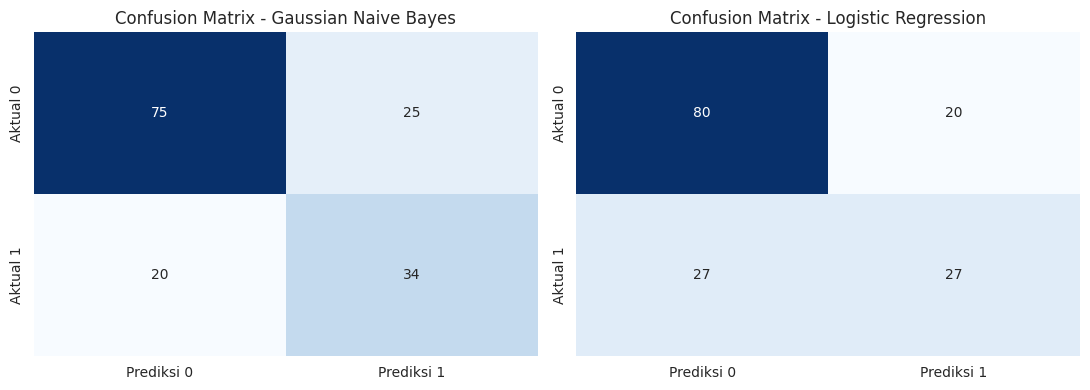

Gaussian Naive Bayes: TN=75, FP=25, FN=20, TP=34
Logistic Regression: TN=80, FP=20, FN=27, TP=27


In [110]:
# Confusion Matrix kedua model.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (nama, pred) in zip(axes, [('Gaussian Naive Bayes', nb_pred),
                                    ('Logistic Regression', lr_pred)]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Prediksi 0', 'Prediksi 1'],
                yticklabels=['Aktual 0', 'Aktual 1'], ax=ax)
    ax.set_title(f'Confusion Matrix - {nama}')

plt.tight_layout()
plt.show()

for nama, pred in [('Gaussian Naive Bayes', nb_pred), ('Logistic Regression', lr_pred)]:
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    print(f'{nama}: TN={tn}, FP={fp}, FN={fn}, TP={tp}')


### Interpretasi Confusion Matrix

Dengan `Outcome = 1` (label diabetes) sebagai kelas positif:

- **True Positive (TP)** — observasi berlabel diabetes yang diprediksi benar sebagai diabetes. NB: 34, LR: 27.
- **True Negative (TN)** — observasi berlabel non-diabetes yang diprediksi benar. NB: 75, LR: 80.
- **False Positive (FP)** — observasi berlabel non-diabetes tetapi diprediksi sebagai diabetes. NB: 25, LR: 20.
- **False Negative (FN)** — observasi berlabel diabetes tetapi diprediksi sebagai non-diabetes. NB: 20, LR: 27.

Perbedaan utama kedua model terletak pada **False Negative**: Naive Bayes menghasilkan 20, Logistic Regression 27. Dalam konteks klasifikasi ini, False Negative berarti model **gagal mengenali observasi yang memiliki label diabetes pada dataset**.

Perlu ditegaskan bahwa angka-angka ini menggambarkan performa **model klasifikasi terhadap label dataset**, dan bukan hasil diagnosis. Notebook ini tidak dapat digunakan untuk menentukan status kesehatan seseorang.


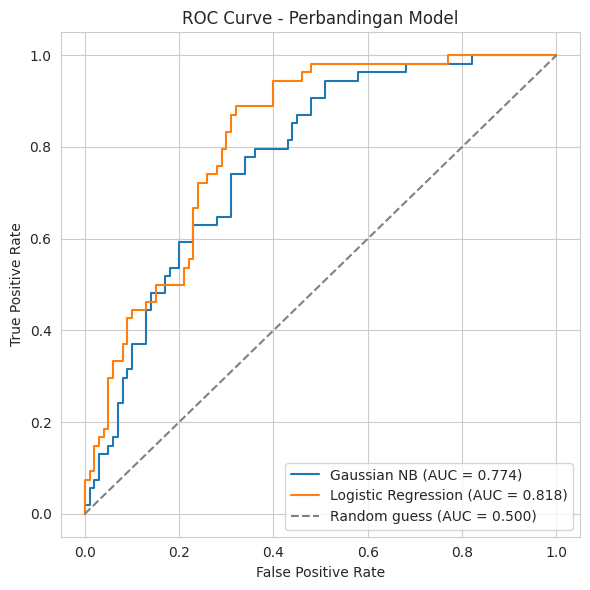

In [111]:
# ROC Curve kedua model.
fpr_nb, tpr_nb, _ = roc_curve(y_test, nb_proba)
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)

plt.figure(figsize=(6, 6))
plt.plot(fpr_nb, tpr_nb, label=f'Gaussian NB (AUC = {roc_auc_score(y_test, nb_proba):.3f})')
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, lr_proba):.3f})')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Random guess (AUC = 0.500)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Perbandingan Model')
plt.legend()
plt.tight_layout()
plt.show()


### Interpretasi

Kedua kurva berada jelas di atas garis diagonal (*random guess*), menunjukkan kedua model memiliki kemampuan diskriminasi yang bermakna. Kurva Logistic Regression berada sedikit di atas Naive Bayes pada sebagian besar rentang, sesuai dengan nilai AUC-nya yang lebih tinggi.

ROC-AUC mengukur kemampuan model **mengurutkan** observasi berdasarkan probabilitas, terlepas dari threshold. Karena itu wajar apabila Logistic Regression unggul di ROC-AUC namun kalah di Recall: pada threshold baku 0,5, Logistic Regression cenderung lebih konservatif dalam memprediksi kelas positif.


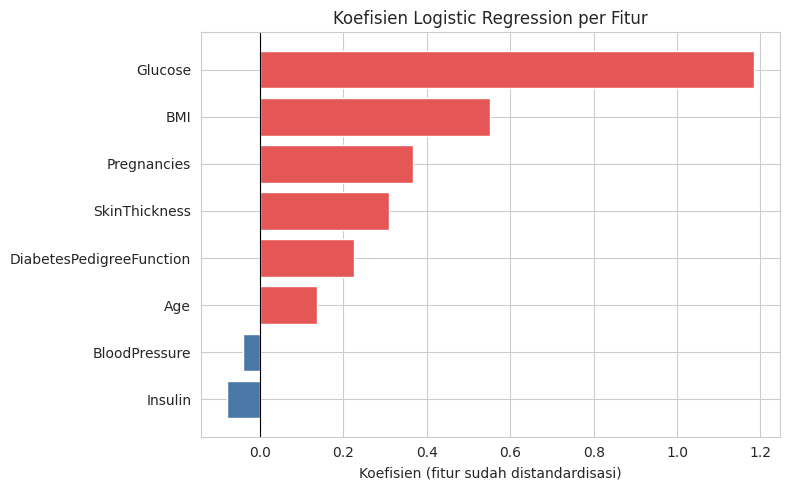

,Fitur,Koefisien,Odds Ratio
1,Glucose,1.1837,3.2663
5,BMI,0.5515,1.7358
0,Pregnancies,0.3676,1.4442
3,SkinThickness,0.3090,1.3621
6,DiabetesPedigreeFunction,0.2249,1.2522
7,Age,0.1362,1.1459
2,BloodPressure,-0.0403,0.9605
4,Insulin,-0.0782,0.9247


In [112]:
# Koefisien Logistic Regression beserta odds ratio.
coef = lr_model.named_steps['clf'].coef_[0]

coef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': coef,
    'Odds Ratio': np.exp(coef)
}).sort_values('Koefisien')

plt.figure(figsize=(8, 5))
warna = ['#E45756' if c > 0 else '#4C78A8' for c in coef_df['Koefisien']]
plt.barh(coef_df['Fitur'], coef_df['Koefisien'], color=warna)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Koefisien (fitur sudah distandardisasi)')
plt.title('Koefisien Logistic Regression per Fitur')
plt.tight_layout()
plt.show()

display(coef_df.sort_values('Koefisien', ascending=False).round(4))


### Interpretasi Koefisien

Karena seluruh fitur sudah distandardisasi, besar koefisien dapat dibandingkan antar fitur. Interpretasi yang tepat adalah dalam kerangka **log-odds**, bukan sebab-akibat:

- **`Glucose` (+1,184; OR ≈ 3,27)** memiliki hubungan positif terkuat dengan log-odds `Outcome = 1`. Artinya, kenaikan satu standar deviasi `Glucose` dikaitkan dengan naiknya odds prediksi kelas diabetes sekitar 3,3 kali, **dengan asumsi fitur lain tetap**.
- **`BMI` (+0,552; OR ≈ 1,74)** dan **`Pregnancies` (+0,368)** memiliki hubungan positif yang lebih lemah.
- **`Insulin` (−0,078; OR ≈ 0,93)** dan **`BloodPressure` (−0,040)** praktis **tidak berkontribusi** terhadap model.

Temuan mengenai `Insulin` sangat penting dan patut digarisbawahi. Sebelum kebocoran dibersihkan, `Insulin` tampil sebagai prediktor terkuat kedua. Setelah nilai imputasi berbasis target dipulihkan, **koefisiennya jatuh hingga mendekati nol**. Ini menjadi bukti tambahan bahwa kekuatan prediktif `Insulin` sebelumnya sebagian besar berasal dari artefak imputasi, bukan dari sinyal biologis pada data terukur.

Sekali lagi, koefisien ini menggambarkan **hubungan pada model**, bukan klaim bahwa variabel tersebut menyebabkan diabetes.


## 4.2 Analisis Sensitivitas: Dampak *Target Leakage*

Bagian ini menguji secara kuantitatif seberapa besar pengaruh kebocoran yang ditemukan pada bagian 1b terhadap metrik evaluasi, dengan membandingkan performa pada data asli (masih bocor) dan data yang sudah dibersihkan.


In [113]:
# Perbandingan performa: data asli (mengandung leakage) vs data yang sudah dibersihkan.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

X_bocor = df.drop(columns='Outcome')      # data asli, masih mengandung leakage
y_bocor = df['Outcome']

baris = []
for nama, model in [('Gaussian Naive Bayes', GaussianNB()),
                    ('Logistic Regression', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))]:
    for tag, Xd, yd in [('Data asli (ada leakage)', X_bocor, y_bocor),
                        ('Setelah dibersihkan', X, y)]:
        s = cross_validate(buat_pipeline(model), Xd, yd, cv=skf, scoring=scoring)
        baris.append({'Model': nama, 'Kondisi Data': tag,
                      **{m.capitalize(): s[f'test_{m}'].mean() for m in scoring}})

sensitivitas = pd.DataFrame(baris).set_index(['Model', 'Kondisi Data']).round(4)
display(sensitivitas)


Accuracy  Precision  Recall  \
Model                Kondisi Data                                           
Gaussian Naive Bayes Data asli (ada leakage)    0.7577     0.6729  0.6268   
                     Setelah dibersihkan        0.7486     0.6633  0.6007   
Logistic Regression  Data asli (ada leakage)    0.7747     0.7188  0.6009   
                     Setelah dibersihkan        0.7721     0.7320  0.5712   

                                                  F1  Roc_auc  
Model                Kondisi Data                              
Gaussian Naive Bayes Data asli (ada leakage)  0.6458   0.8415  
                     Setelah dibersihkan      0.6273   0.8190  
Logistic Regression  Data asli (ada leakage)  0.6511   0.8581  
                     Setelah dibersihkan      0.6363   0.8419

### Interpretasi Analisis Sensitivitas

Pembersihan kebocoran menurunkan seluruh metrik secara konsisten. Penurunan terbesar terjadi pada **ROC-AUC**, yaitu sekitar **0,02** untuk kedua model, serta pada F1-Score.

Dua kesimpulan penting:

1. **Metrik pada data asli terlalu optimistis.** Angka yang dilaporkan tanpa pembersihan menggambarkan sebagian kemampuan model "membaca jawaban" dari nilai imputasi, bukan murni kemampuan prediksi dari karakteristik pasien.
2. **Besarnya dampak relatif moderat untuk kedua model ini.** Penurunan ~0,02 memang tidak dramatis. Penyebabnya, baik Logistic Regression maupun Gaussian Naive Bayes bersifat linear/probabilistik sederhana sehingga tidak dapat mengeksploitasi aturan tajam "nilai tepat 102,5 → kelas 0" secara maksimal.

Perlu diperingatkan bahwa **dampaknya akan jauh lebih besar pada model berbasis pohon** (seperti Decision Tree atau Random Forest), yang sangat mudah menangkap aturan berbasis nilai eksak seperti ini. Karena itu, pembersihan ini tetap wajib dilakukan meskipun dampaknya pada dua model di tugas ini tergolong moderat.


## 4.3 Stratified 5-Fold Cross-Validation

Evaluasi pada satu kali split dapat dipengaruhi kebetulan pembagian data, apalagi test set hanya berisi 154 observasi. Cross-validation memberikan estimasi yang lebih stabil.


In [114]:
# Stratified 5-Fold CV memakai Pipeline (imputasi & scaling dipelajari ulang tiap fold).
cv_hasil, cv_gap = {}, []

for nama, model in [('Gaussian Naive Bayes', GaussianNB()),
                    ('Logistic Regression', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))]:
    s = cross_validate(buat_pipeline(model), X, y, cv=skf,
                       scoring=scoring, return_train_score=True)
    cv_hasil[nama] = {m.capitalize(): s[f'test_{m}'].mean() for m in scoring}
    cv_gap.append({'Model': nama,
                   'F1 Train': s['train_f1'].mean(),
                   'F1 Test': s['test_f1'].mean(),
                   'Gap (Train - Test)': s['train_f1'].mean() - s['test_f1'].mean()})

display(pd.DataFrame(cv_hasil).T.round(4))
print('\nPemeriksaan overfitting:')
display(pd.DataFrame(cv_gap).set_index('Model').round(4))


,Accuracy,Precision,Recall,F1,Roc_auc
Gaussian Naive Bayes,0.7486,0.6633,0.6007,0.6273,0.8190
Logistic Regression,0.7721,0.7320,0.5712,0.6363,0.8419



Pemeriksaan overfitting:


,F1 Train,F1 Test,Gap (Train - Test)
Model,,,
Gaussian Naive Bayes,0.6407,0.6273,0.0134
Logistic Regression,0.6401,0.6363,0.0039


### Interpretasi

**Hasil cross-validation (lebih stabil daripada satu kali split):**

- **Gaussian Naive Bayes**: Accuracy 0,749 | Precision 0,663 | Recall 0,601 | F1 0,627 | ROC-AUC 0,819
- **Logistic Regression**: Accuracy 0,772 | Precision 0,732 | Recall 0,571 | F1 0,636 | ROC-AUC 0,842

Pola trade-off yang muncul pada single split **tetap konsisten**: Naive Bayes lebih unggul pada Recall, sedangkan Logistic Regression lebih unggul pada Precision, Accuracy, dan ROC-AUC. F1-Score keduanya berdekatan (0,627 vs 0,636), sehingga selisihnya terlalu kecil untuk menyatakan satu model unggul secara meyakinkan.

**Pemeriksaan overfitting:** selisih F1 antara data train dan test sangat kecil untuk kedua model (di bawah 0,02). Ini menunjukkan model berada pada kondisi **good fit** — tidak menghafal data train. Bahkan sebaliknya, nilai F1 train yang juga tidak tinggi mengindikasikan keterbatasan performa lebih disebabkan oleh **tumpang tindih antar kelas pada data** (sebagaimana terlihat pada EDA), bukan oleh model yang terlalu sederhana maupun terlalu kompleks.


# 5. Analisis

## 5.1 Perbandingan Gaussian Naive Bayes vs Logistic Regression

Berdasarkan hasil cross-validation yang merupakan dasar pembanding paling stabil:

| Metrik | Gaussian Naive Bayes | Logistic Regression | Model yang unggul |
|---|---:|---:|---|
| Accuracy | 0,749 | 0,772 | Logistic Regression |
| Precision | 0,663 | 0,732 | Logistic Regression |
| Recall | 0,601 | 0,571 | Gaussian Naive Bayes |
| F1-Score | 0,627 | 0,636 | Selisih sangat kecil |
| ROC-AUC | 0,819 | 0,842 | Logistic Regression |

**Penjelasan trade-off.** Naive Bayes memperoleh Recall lebih tinggi tetapi Precision lebih rendah, artinya model ini lebih "longgar" dalam memprediksi kelas positif sehingga menangkap lebih banyak observasi diabetes, dengan konsekuensi lebih banyak False Positive. Logistic Regression bersikap sebaliknya: lebih selektif, sehingga Precision lebih tinggi namun lebih banyak observasi diabetes yang terlewat.

Perbedaan ini dapat dijelaskan dari asumsi masing-masing. Naive Bayes mengasumsikan fitur saling bebas jika kelas diketahui, padahal pada dataset ini terdapat korelasi antar fitur yang cukup jelas (`SkinThickness`–`BMI` = 0,566; `Pregnancies`–`Age` = 0,544). Akibatnya, informasi yang saling tumpang tindih terhitung berulang kali, dan probabilitas yang dihasilkan cenderung terlalu ekstrem. Logistic Regression memodelkan kombinasi linear seluruh fitur secara bersamaan, sehingga dapat memberi bobot yang lebih proporsional pada fitur yang berkorelasi.

**Kesimpulan perbandingan:** Logistic Regression unggul pada lebih banyak metrik dan memiliki ROC-AUC lebih tinggi, tetapi Gaussian Naive Bayes unggul pada Recall. Pemilihan model karenanya bergantung pada metrik yang diprioritaskan, bukan pada klaim bahwa salah satu model pasti lebih baik.


## 5.2 Mengapa Performa Berada di Kisaran Menengah

Nilai F1-Score sekitar 0,63 dan ROC-AUC sekitar 0,82–0,84 sebaiknya tidak dibaca sebagai kegagalan. Tiga penjelasan yang didukung hasil eksperimen pada notebook ini:

1. **Tumpang tindih antar kelas bersifat nyata.** Analisis pada bagian 1c.1 menunjukkan banyak observasi dengan glukosa kategori IGT atau BMI obesitas tetapi berlabel `Outcome = 0`. Selama kedua kelas menempati rentang nilai yang sama, tidak ada model yang mampu memisahkannya secara sempurna.
2. **Gap train-test yang sangat kecil** menunjukkan keterbatasan berasal dari data, bukan dari pemilihan model atau overfitting.
3. **Sebagian "performa" pada versi awal ternyata semu.** Setelah kebocoran target dibersihkan, metrik turun. Angka yang lebih rendah namun bersih justru **lebih jujur dan lebih dapat dipertanggungjawabkan** daripada angka tinggi yang berasal dari kebocoran.


## 5.3 Keterbatasan

1. **Sisa kebocoran yang tidak dapat dipulihkan.** Hanya nilai imputasi dengan jejak pecahan (102,5; 169,5; 74,5) yang dapat diidentifikasi. Nilai imputasi yang kebetulan berupa bilangan bulat — terindikasi pada `SkinThickness` (nilai 27 dan 32) serta `BloodPressure` (nilai 70) — tidak dapat dibedakan dari data asli. Metrik yang dilaporkan karenanya **mungkin masih sedikit optimistis**.
2. **Notebook ini bukan alat diagnosis.** Seluruh analisis merupakan pemodelan klasifikasi terhadap label pada dataset. Model tidak mendiagnosis siapa pun dan tidak dapat menggantikan pemeriksaan tenaga medis.
3. **Keterbatasan populasi.** Dataset Pima berasal dari populasi perempuan Pima Indian berusia minimal 21 tahun, sehingga hasil ini tidak otomatis berlaku untuk populasi lain.
4. **Asumsi Naive Bayes tidak sepenuhnya terpenuhi** (independensi bersyarat dan normalitas per kelas), sebagaimana dibahas pada bagian 3.1.
5. **Nilai `Glucose` tampaknya terpotong pada 199 mg/dL**, sehingga tidak ada observasi yang mencapai ambang diabetes 2 jam OGTT (≥ 200). Informasi pada rentang atas kemungkinan hilang.
6. **Ukuran test set kecil** (154 observasi, 54 di antaranya kelas positif), sehingga metrik pada satu kali split memiliki variabilitas cukup besar. Karena itu cross-validation dijadikan dasar pembanding utama.


# 6. Kesimpulan dan Saran

## Kesimpulan

1. **Ditemukan *target leakage* di dalam dataset.** Nilai `0` pada `Insulin` dan `BloodPressure` telah diisi oleh penyedia dataset menggunakan **median per kelompok `Outcome`**. Akibatnya, 374 baris (48,7% dari data) memiliki nilai `Insulin` yang memetakan label secara sempurna. Kebocoran ini sudah diperbaiki sejauh yang dapat diidentifikasi, dan dampaknya diukur secara eksplisit pada bagian 4.2.
2. **Aturan domain knowledge WHO telah dikoreksi.** Ambang 110/126 mg/dL yang sebelumnya digunakan adalah kriteria **gula darah puasa**, sedangkan kolom `Glucose` pada dataset ini merupakan nilai **2 jam OGTT** yang ambangnya adalah 140 dan 200 mg/dL. Setelah dikoreksi, hubungan yang diperoleh tetap kuat dan bersifat *data-driven*: proporsi label diabetes naik dari 23,0% (Glucose < 140) menjadi 68,8% (Glucose 140–199).
3. **Penandaan "anomali" pada 68% data telah diperbaiki menjadi analisis tumpang tindih.** Observasi dengan faktor risiko tinggi namun berlabel non-diabetes adalah data yang sah, bukan kesalahan, dan justru menjelaskan batas alamiah performa model.
4. **Kedua model menghasilkan performa yang berdekatan dengan trade-off yang jelas.** Logistic Regression unggul pada Accuracy, Precision, dan ROC-AUC; Gaussian Naive Bayes unggul pada Recall. F1-Score keduanya hanya berselisih tipis (0,627 vs 0,636), sehingga tidak tepat menyatakan satu model mutlak lebih baik.
5. **`Glucose` merupakan prediktor terkuat dan paling dapat dipercaya**, dengan koefisien +1,184 (OR ≈ 3,27) dan korelasi 0,496 yang tidak terpengaruh kebocoran. Sebaliknya, kekuatan `Insulin` sebagian besar terbukti merupakan artefak imputasi — koefisiennya jatuh mendekati nol setelah data dibersihkan.
6. **Model berada pada kondisi good fit**, dengan gap F1 train-test di bawah 0,02, sehingga performa yang ada mencerminkan batas informasi pada data, bukan overfitting.

## Saran

1. **Gunakan dataset Pima versi asli (UCI)** yang masih memuat nilai `0`, agar imputasi dapat dilakukan sendiri secara benar (tanpa melibatkan target, di dalam pipeline). Ini adalah perbaikan paling berdampak untuk kelanjutan proyek.
2. **Selalu periksa integritas dataset sebelum pemodelan**, khususnya nilai berulang yang tidak wajar, dengan menghubungkannya ke variabel target — pemeriksaan sederhana `value_counts()` pada notebook ini sudah cukup untuk membongkar kebocoran tersebut.
3. **Eksplorasi threshold klasifikasi** sebagai alternatif menaikkan Recall tanpa mengganti model, dengan catatan threshold harus dipilih berdasarkan data validasi atau cross-validation, **bukan dari test set**.
4. **Pertimbangkan `class_weight='balanced'` pada Logistic Regression** apabila prioritasnya adalah menekan False Negative. Opsi ini tidak mengganti algoritma sehingga tetap sesuai ketentuan tugas.
5. **Laporkan metrik beserta konteks kebocorannya.** Apabila hasil dibandingkan dengan pekerjaan lain yang memakai dataset Kaggle yang sama, perlu disadari bahwa angka mereka kemungkinan besar masih mengandung kebocoran ini sehingga tampak lebih tinggi.
